#**ASSIGNMENT 2: NEURAL NETWORK FOR IMAGE CLASSIFICATION**


In this assignment, you will build a simple neural network for `cat` vs `non-cat` binary classification. All the basic building blocks of a neural network will be built in Python. As a result, this assignment will help you understanding the fundamental mechanisms of neural network models. Specifically, you will learn how to:
*   Load and pre-process dataset for training neural network models.
*   Build and apply a neural network to supervised learning in Python.
*   Build a two layer network in Tensorflow.

**Specific Tasks:**
* Implement SIGMOID and RELU activation functions.
* Initialize and update the network parameters.
* Implement forward propagation and backward propagation functions.
* Put various pieces together to build a two layer network for classification.
* Reimplement the same model using Tensorflow.

You have a total fo 10 graded activities. You can complete the first 6 activities on Oct. 3 (recitation). PLease refer to the lectures 7 & 8 to complete these 6 activities. Activities 7-10 can be completed in the next two recitations.  

**Due date:** *Please include your last name in the .ipynb file and submit the renamed file to Teams by* **October 16.** *For instance, a student with the last name 'abc' would rename their file to Binary_classifier_activities_abc.ipynb.* Your submision notebook must have all the cells executed and the outputs displayed.


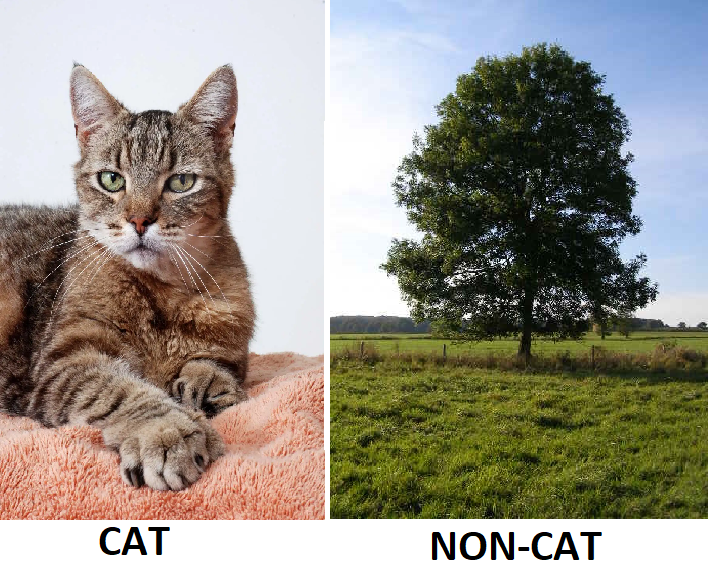

Let's get started!

As usual, before executing the following python code, you have to upload the Binary_Classifier folder to your Google drive. Download the assignment from MS Teams and upload it into the `My Drive/Colab Notebooks` of your google drive. Now, let us mount the google drive and set the working directory to `My Drive/Colab Notebooks/Binary_Classifier`. Note: In assignment 1, some students uploaded the `Hybrid_Images` folder to `My Drive/Colab Notebooks/Hybrid_Images/` instead of `My Drive/Colab Notebooks/` and ran the notebook from `My Drive/Colab Notebooks/Hybrid_Images/Hybrid_Images`, causing errors due to incorrect image paths.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/gdrive')
root_dir = "/content/gdrive/MyDrive/"
project_folder = "Colab Notebooks/Binary_Classifier/"
os.chdir(root_dir+project_folder)

Mounted at /content/gdrive



**Packages:**

Let us first import all the packages that you will need during this assignment.

* **numpy**: is the fundamental package for scientific computing with Python.
* **matplotlib**: is a library to plot graphs in Python.
* **h5py:** is a common package to interact with a dataset that is stored on an H5 file.
* **np.random.seed(1)** is used to keep all the random function calls consistent. It will help us grade your work.

Helper functions:
A few utility funtions designed to visualize model's predictions, activation functions helpers and test functions are available in `utility.py`, `activation_function.py` and `testCases_v4.py` respectively.


In [ ]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
import sys
from activation_function import sigmoid_backward, relu_backward
from testCases_v4 import *
from Util import *

#enables inline plotting in notebook cells
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots to 5 inches x 4 inches
plt.rcParams['image.interpolation'] = 'bilinear' #Sets the default interpolation method for displaying images to bilinear.
plt.rcParams['image.cmap'] = 'gray' #Sets the default colormap for images to grayscale.

#Loads the autoreload extension, which can automatically reload Python modules.
%load_ext autoreload
 #Enables autoreloading of all modules (except those excluded) every time before executing the Python code.
%autoreload 2


np.random.seed(1) #Sets a fixed random seed for NumPy's random number generator, ensuring reproducibility of random operations.

# **1. Data Loading and Pre-processing**

You are given a traning and testing dataset (".h5" files, see https://docs.h5py.org/en/stable/high/dataset.html for more details on how .h5 files are processed in python) inside `dataset` folder containing:

- a training set of `m_train` images labeled as cat (`y=1`) or non-cat (`y=0`)
- a test set of `m_test` images labeled as cat or non-cat
- each image is of `shape (num_px, num_px, 3)` where 3 is for the 3 channels (RGB). Thus, each image is square of height = `num_px` and width = `num_px`.

Let us familiarize ourselves with the dataset. Please run the following code to load the data.

In [ ]:
#Read training dataset
train_dataset = h5py.File('./datasets/train_catvnoncat.h5', "r")

# your train set features
train_set_x_orig = np.array(train_dataset["train_set_x"][:])

# your train set labels
train_set_y_orig = np.array(train_dataset["train_set_y"][:])

#Read test dataset
test_dataset = h5py.File('./datasets/test_catvnoncat.h5', "r")

# your test set features
test_set_x_orig = np.array(test_dataset["test_set_x"][:])

# your test set labels
test_set_y_orig = np.array(test_dataset["test_set_y"][:])

# the list of classes
classes = np.array(test_dataset["list_classes"][:])

train_set_y = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

We added "`_orig`" at the end of image datasets (train and test) because these are original data before the preprocessing. A preprocessing is done to get `train_set_x` and `test_set_x` (the labels `train_set_y` and `test_set_y` do not need any preprocessing).

Each line of your `train_set_x_orig` and `test_set_x_orig` is an array representing an image. You can visualize an example by running the following code. In our dataset, `train_set_y` contains class indices and `classes` contains the corresponding class labels as byte strings. The following print line would retrieve the human-readable class label for the training image at `index`. Feel free to change the `index` value and re-run to see other images.

y = [0], it's a 'non-cat' picture.


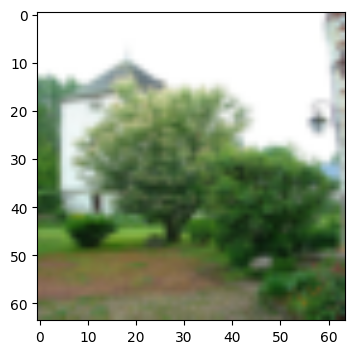

In [ ]:
# Example of a "non-cat" image
index = 55
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")


Example of a cat image.

y = [1], it's a 'cat' picture.


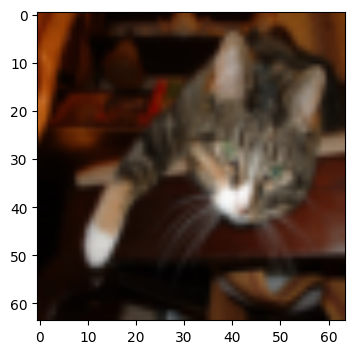

In [ ]:
# Example of a "cat" image
index = 148
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

Many software bugs in deep learning come from having incompatible matrix/vector dimensions. If you can keep your matrix/vector dimensions straight you will go a long way toward eliminating many bugs.

Firs we find the values for:

- `m_train` (number of training examples)
- `m_test` (number of test examples)
- `num_px` (= height = width of a training image)

Remember that train_set_x_orig is a numpy-array of shape (m_train, num_px, num_px, 3). For instance, you can access `m_train` by executing
 `train_set_x_orig.shape[0]`.

In [ ]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]


print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


Reshape the training and test data sets so that images of size (64,64,3) are flattened into single vectors of shape (12288, 1), see the figure below.

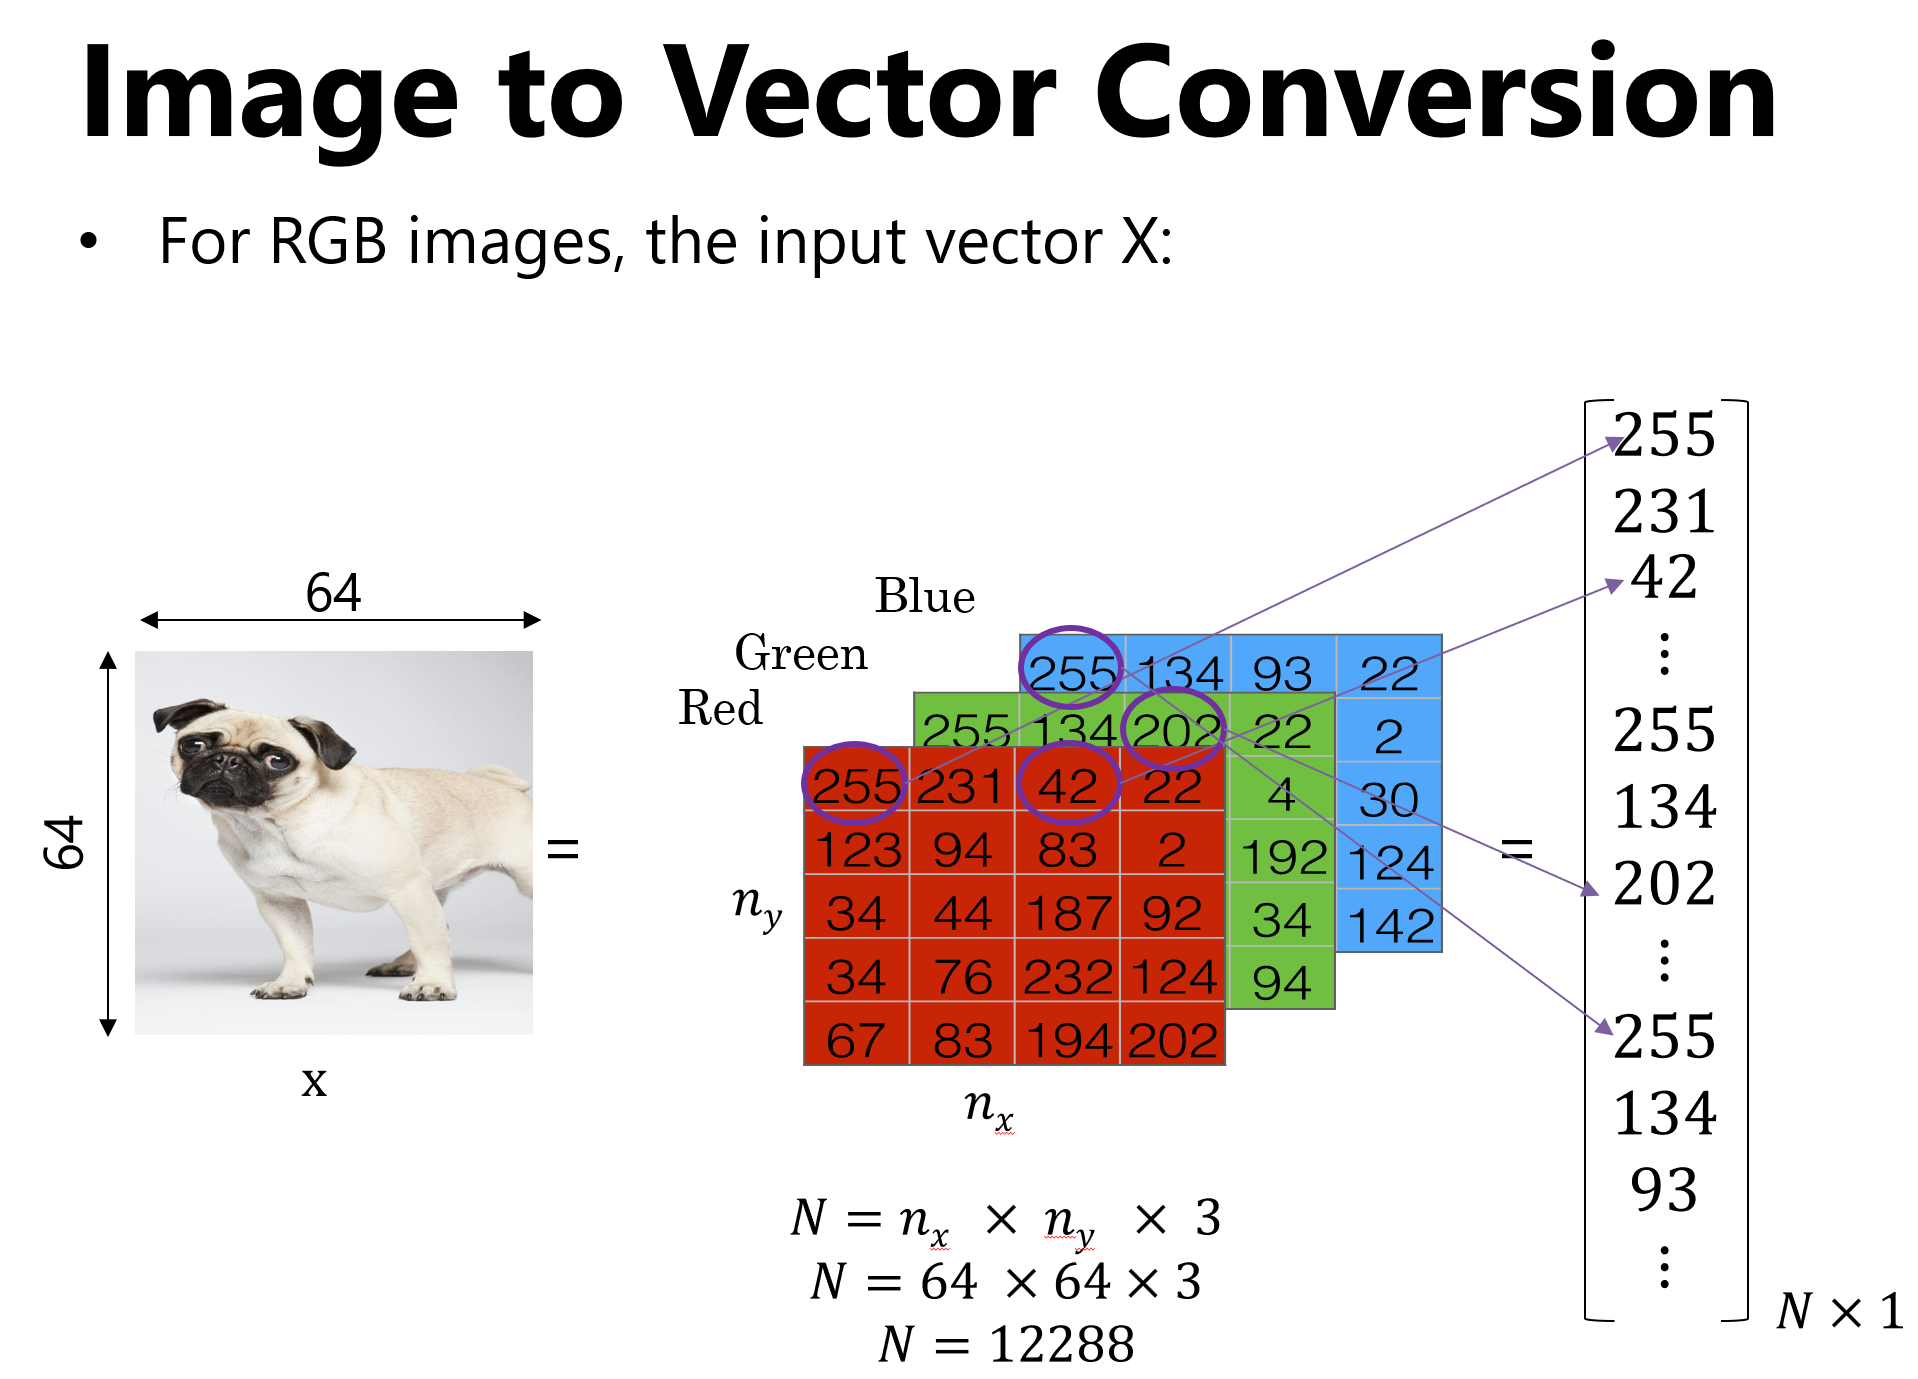


A trick when you want to flatten a matrix X of shape (a,b,c,d) to a matrix X_flatten of shape (bcd, a) is to use:

`X_flatten = X.reshape(X.shape[0], -1).T`  

The function `X.reshape()` will keep the first dimension unchanged (`X.shape[0]`). The -1 as the second argument of `X.reshape()` tells NumPy to automatically calculate the size of this dimension to fit all the data. This effectively flattens all dimensions after the first into one long dimension.

Note that the above figure shows the conversion of only one image. Our `X` has 209 training images each with `64 x 64 x 3` sized images. So you want to convert it to `X_flatten` having a shape of `(12288, 209)`.

In [ ]:
# Reshape the training and test examples

train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0],-1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0],-1).T


print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
print ("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
sanity check after reshaping: [17 31 56 22 33]


To represent color images, the red, green and blue channels (RGB) must be specified for each pixel, and so the pixel value is actually a vector of three numbers ranging from 0 to 255.

One common preprocessing step in machine learning is to center and standardize your dataset, meaning that you substract the mean of the whole numpy array from each example, and then divide each example by the standard deviation of the whole numpy array. But for picture datasets, it is simpler and more convenient and works almost as well when you divide image pixels by 255. Essentially, each row of the dataset should be divided by 255 (the maximum value of a pixel channel).

Let us standardize our dataset.

In [ ]:
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

Let us recap what we have learnt so far:

* Identify the dimensions and shapes of the datasets (m_train, m_test, num_px, ...)

* Reshape the datasets such that each example is now a vector of size (num_px * num_px * 3, 1)

* "Standardize" the data

# **2. Building Blocks of the Neural Network**

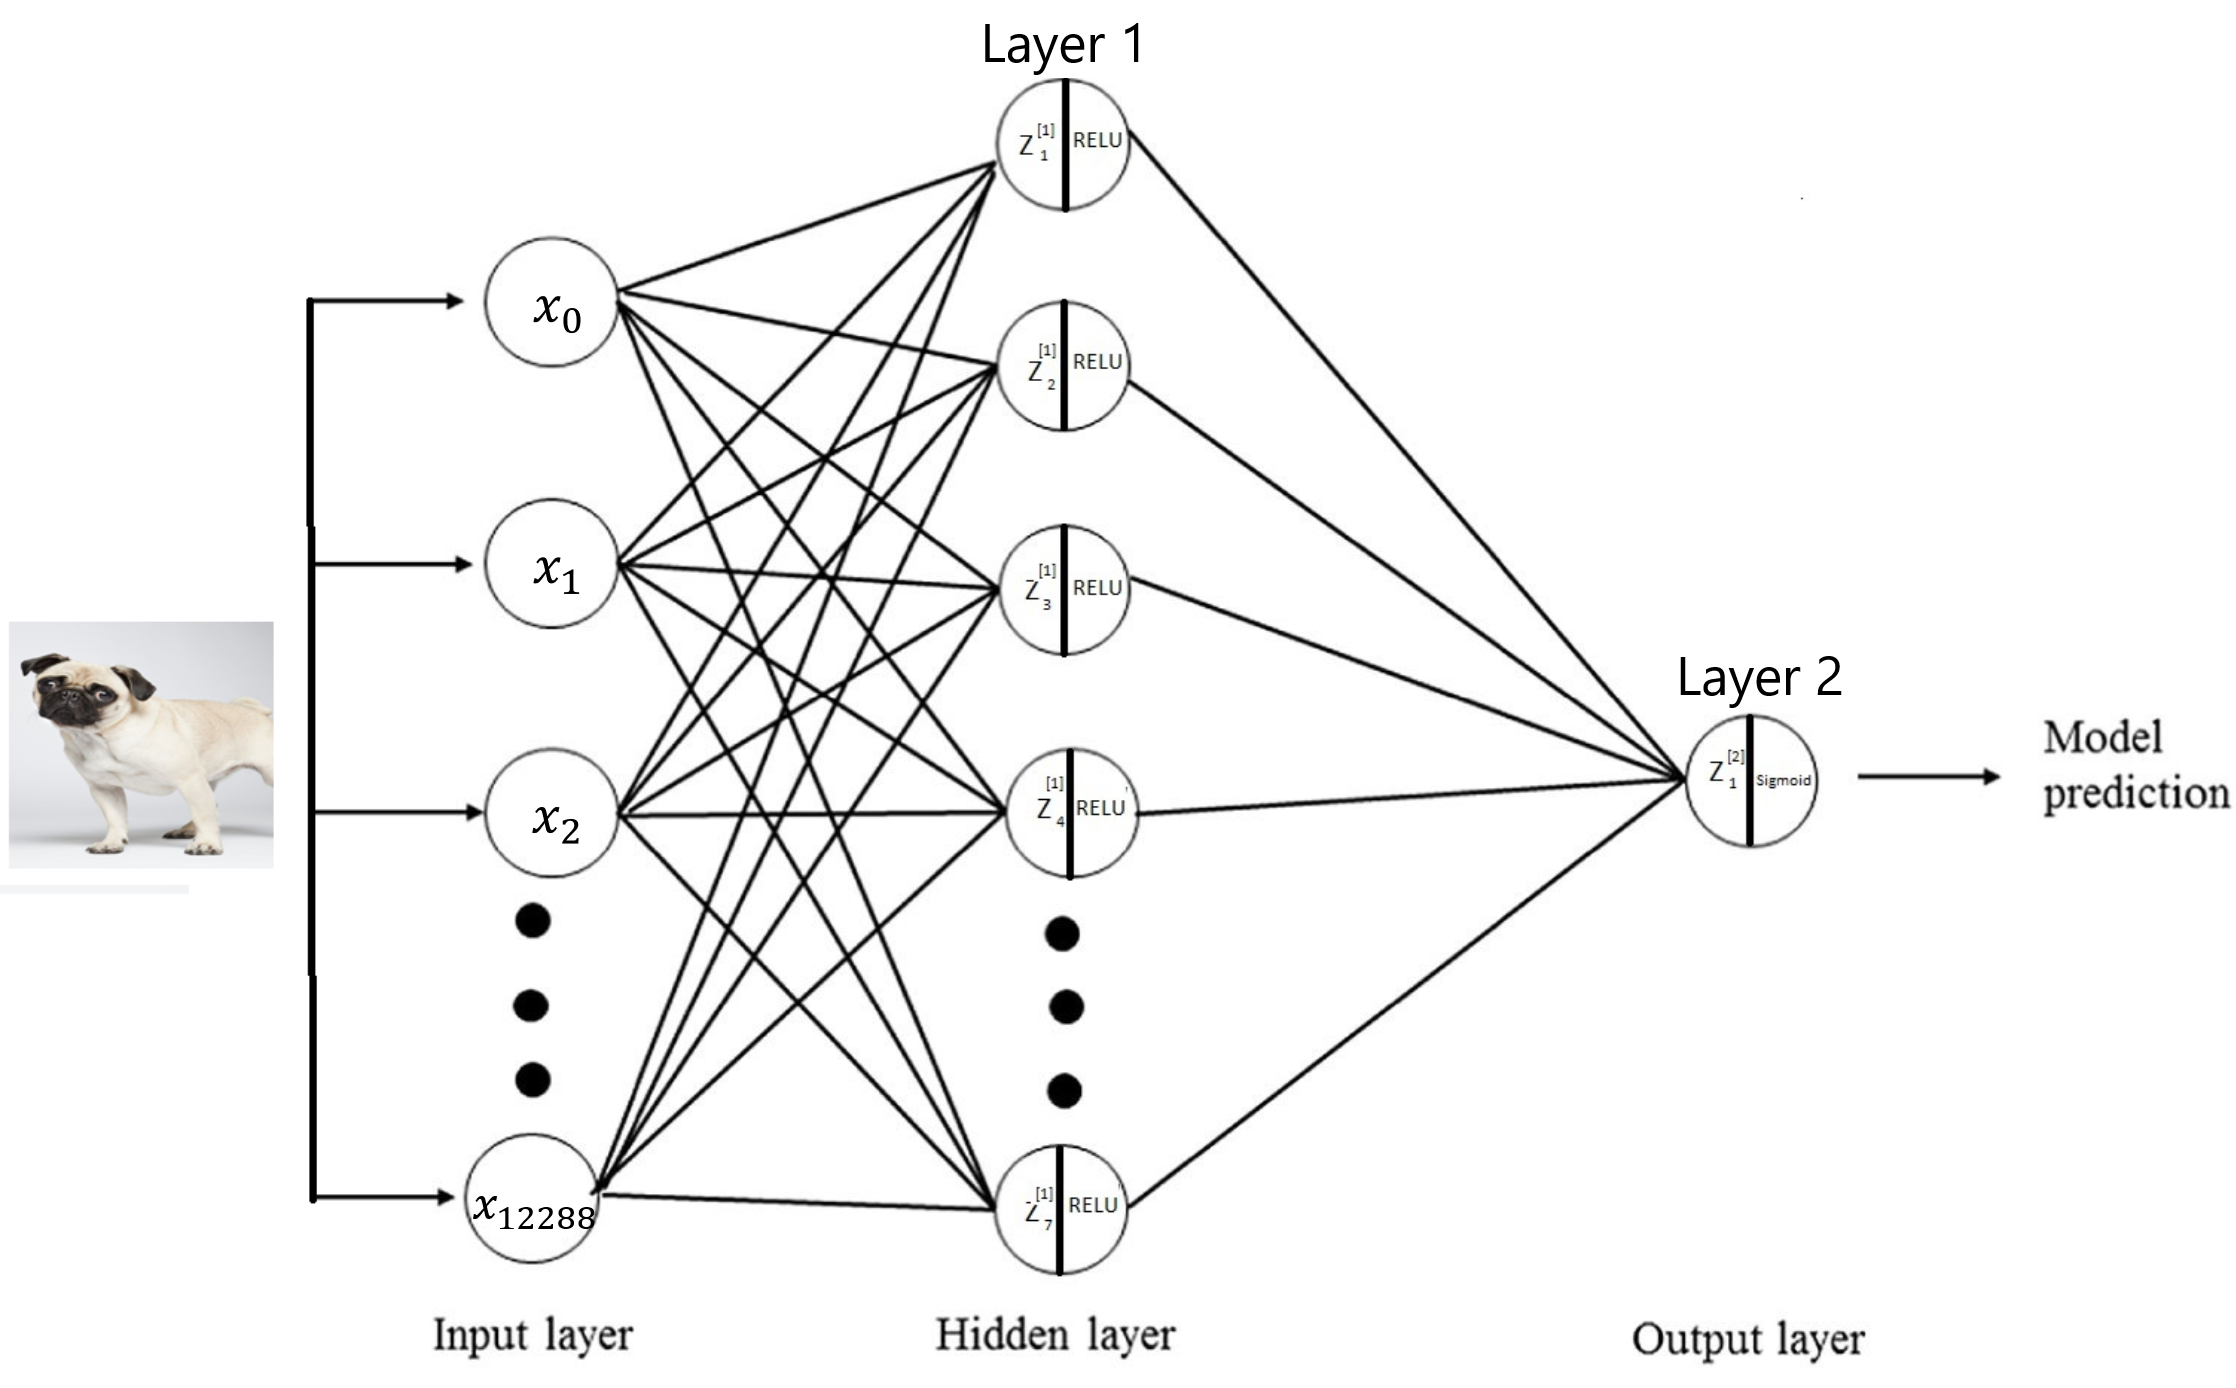



To build your neural network, you will be implementing several "helper functions". These helper functions will be used in the next section to build a two-layer neural network as shown in the figure above (refer to Lacture 8 slides). Each small helper function you will implement will have detailed instructions that will walk you through the necessary steps. Here is an outline of this task in this part, you will:



* Implement the activation functions

* Initialize the parameters for a two-layer network.

* Implement the forward propagation module.

* Compute the loss.

* Implement the backward propagation module.

* Finally update the parameters.

Note that for every forward function, there is a corresponding backward function. That is why at every step of your forward module, you will be storing some values in a cache. The cached values are useful for computing the gradients. In the backpropagation module (we will discuss this before next recitation) you will use the cached values to calculate the gradients. This assignment will show you exactly how to carry out each of these steps.

## **2.1 Activation Functions**

Activation functions are integral part of deep neural networks. Activation functions decide whether to activate or deactivate neurons to get the desired output. Further, it performs a nonlinear transformation on the input to get better results on complex neural network.

In this assignment, we will use non-linear activation functions such as SIGMOID and RELU. RELU will be used for neurons in the hidden layer and SIGMOID will be used for the output neuron.

**SIGMOID:**


Sigmoid functions are characterized by "S"-shaped curves. Please find below a common sigmoid function called logistic function (discussed in Lecture 8).

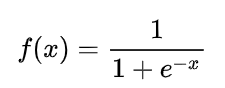

The corresponding plot is given below.

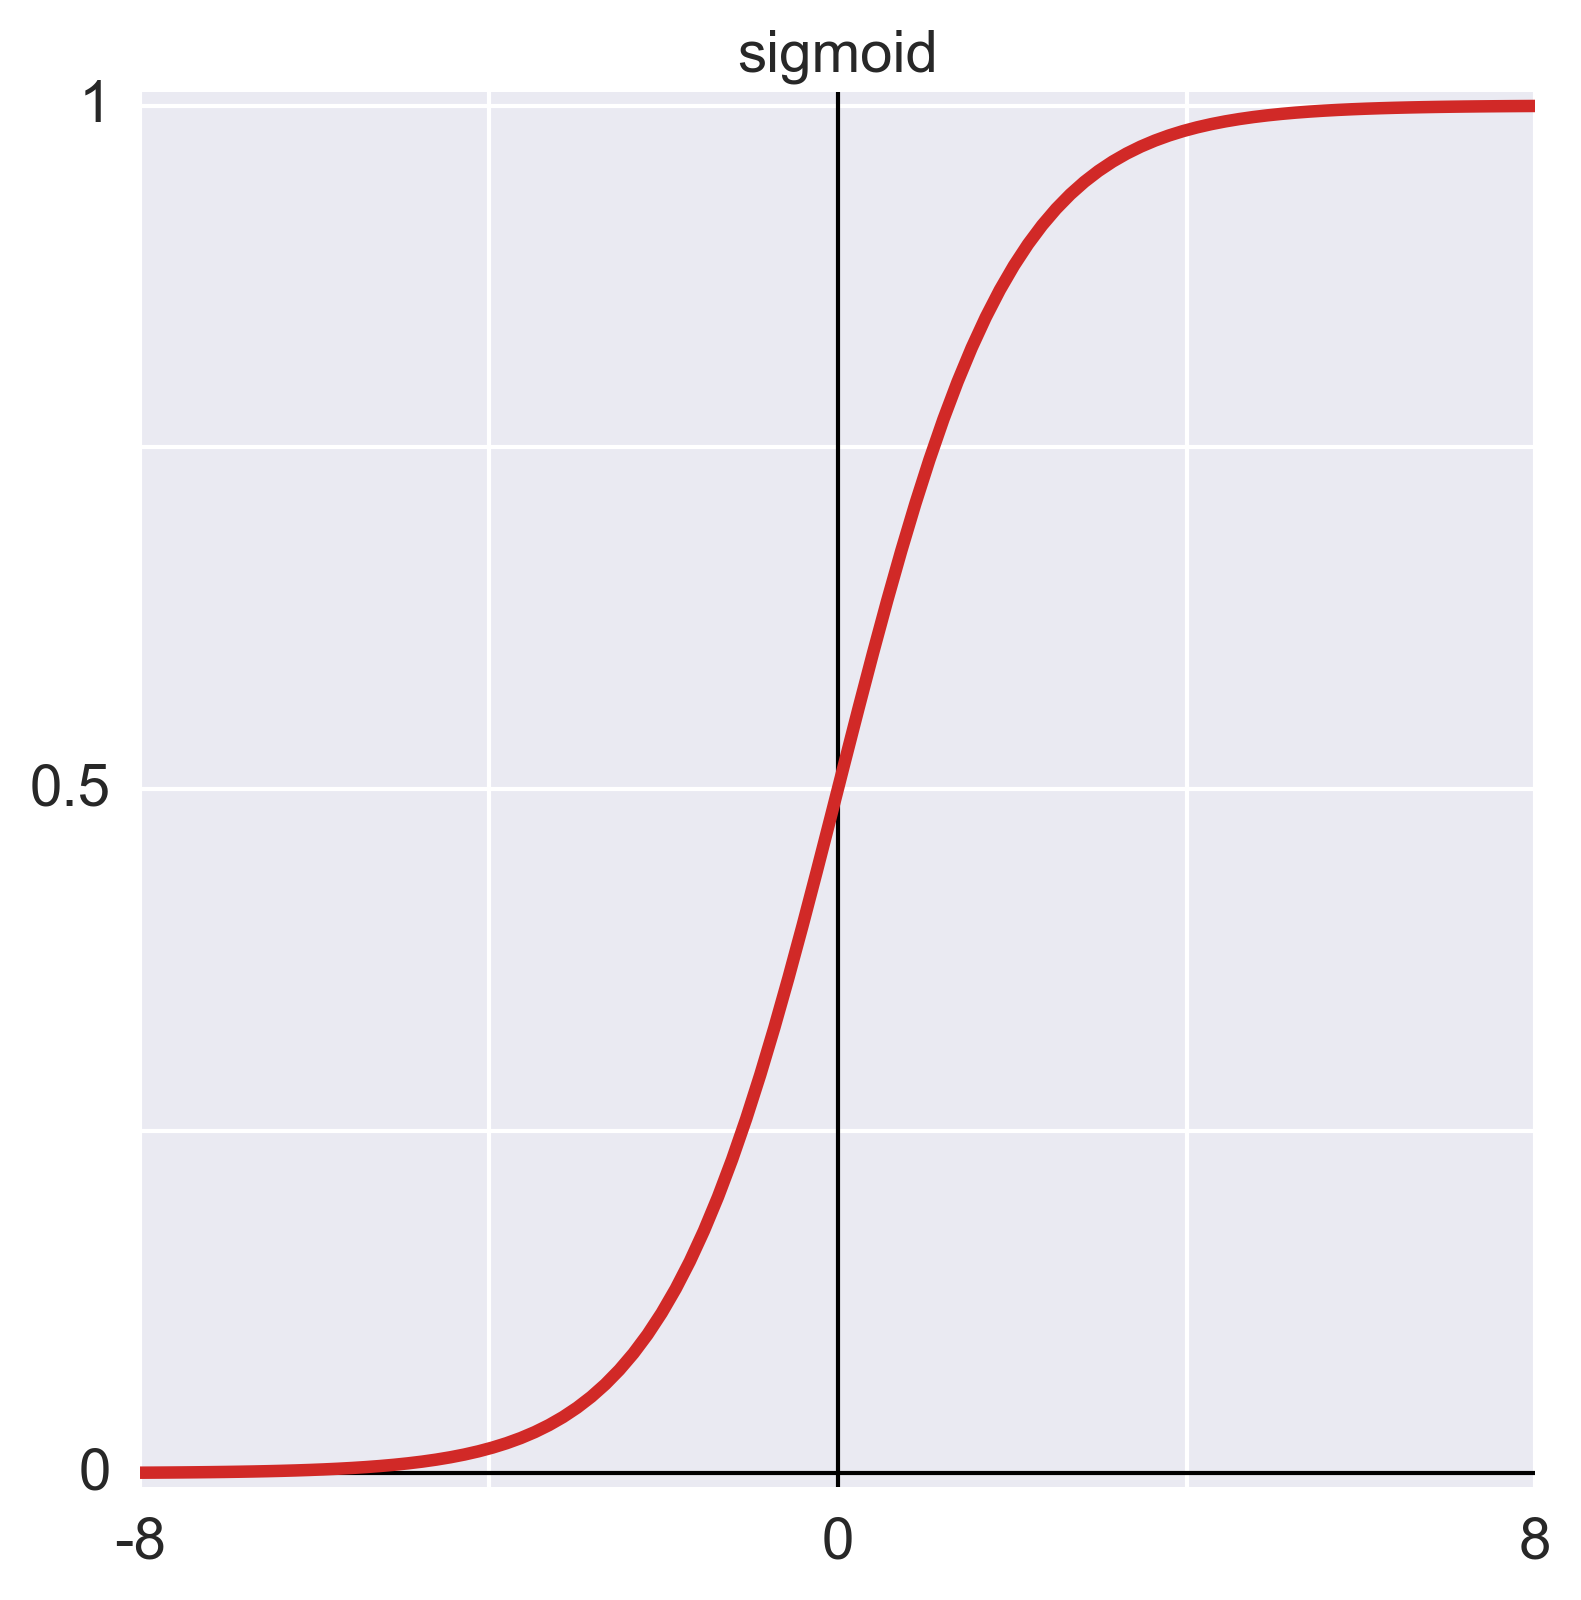

Below we will implement the sigmoid activation function. Your task is to fill out the blanks where you will implement the above function for the variable $Z$. Note that $Z$ is a numpy array. So this is a vectorized implementation.

The function returns two items: the activation value `a` and a `cache` that contains `Z` (it is what we will feed into the corresponding backward function). To use it you can just call:

`A, activation_cache = sigmoid(Z)`

HINT: You can calculate the exponentials of all elements in an array using `np.exp()` function.

In [ ]:
#Graded Activity 1
def sigmoid(Z):
    """
    Implements the sigmoid activation in numpy

    Arguments:
    Z -- numpy array of any shape

    Returns:
    A -- output of sigmoid(z), same shape as Z
    cache -- returns Z as well, useful during backpropagation
    """
    #code the function, see https://numpy.org/doc/stable/reference/generated/numpy.exp.html for np.exp()
    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache

Next we will implement RELU activation function.

**RELU:**

Relu is a piecewise linear function that will output the input directly if it is positive, otherwise, it will output zero. The function and the corresponding plot is given below.

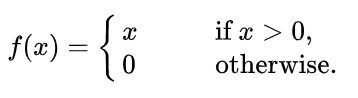

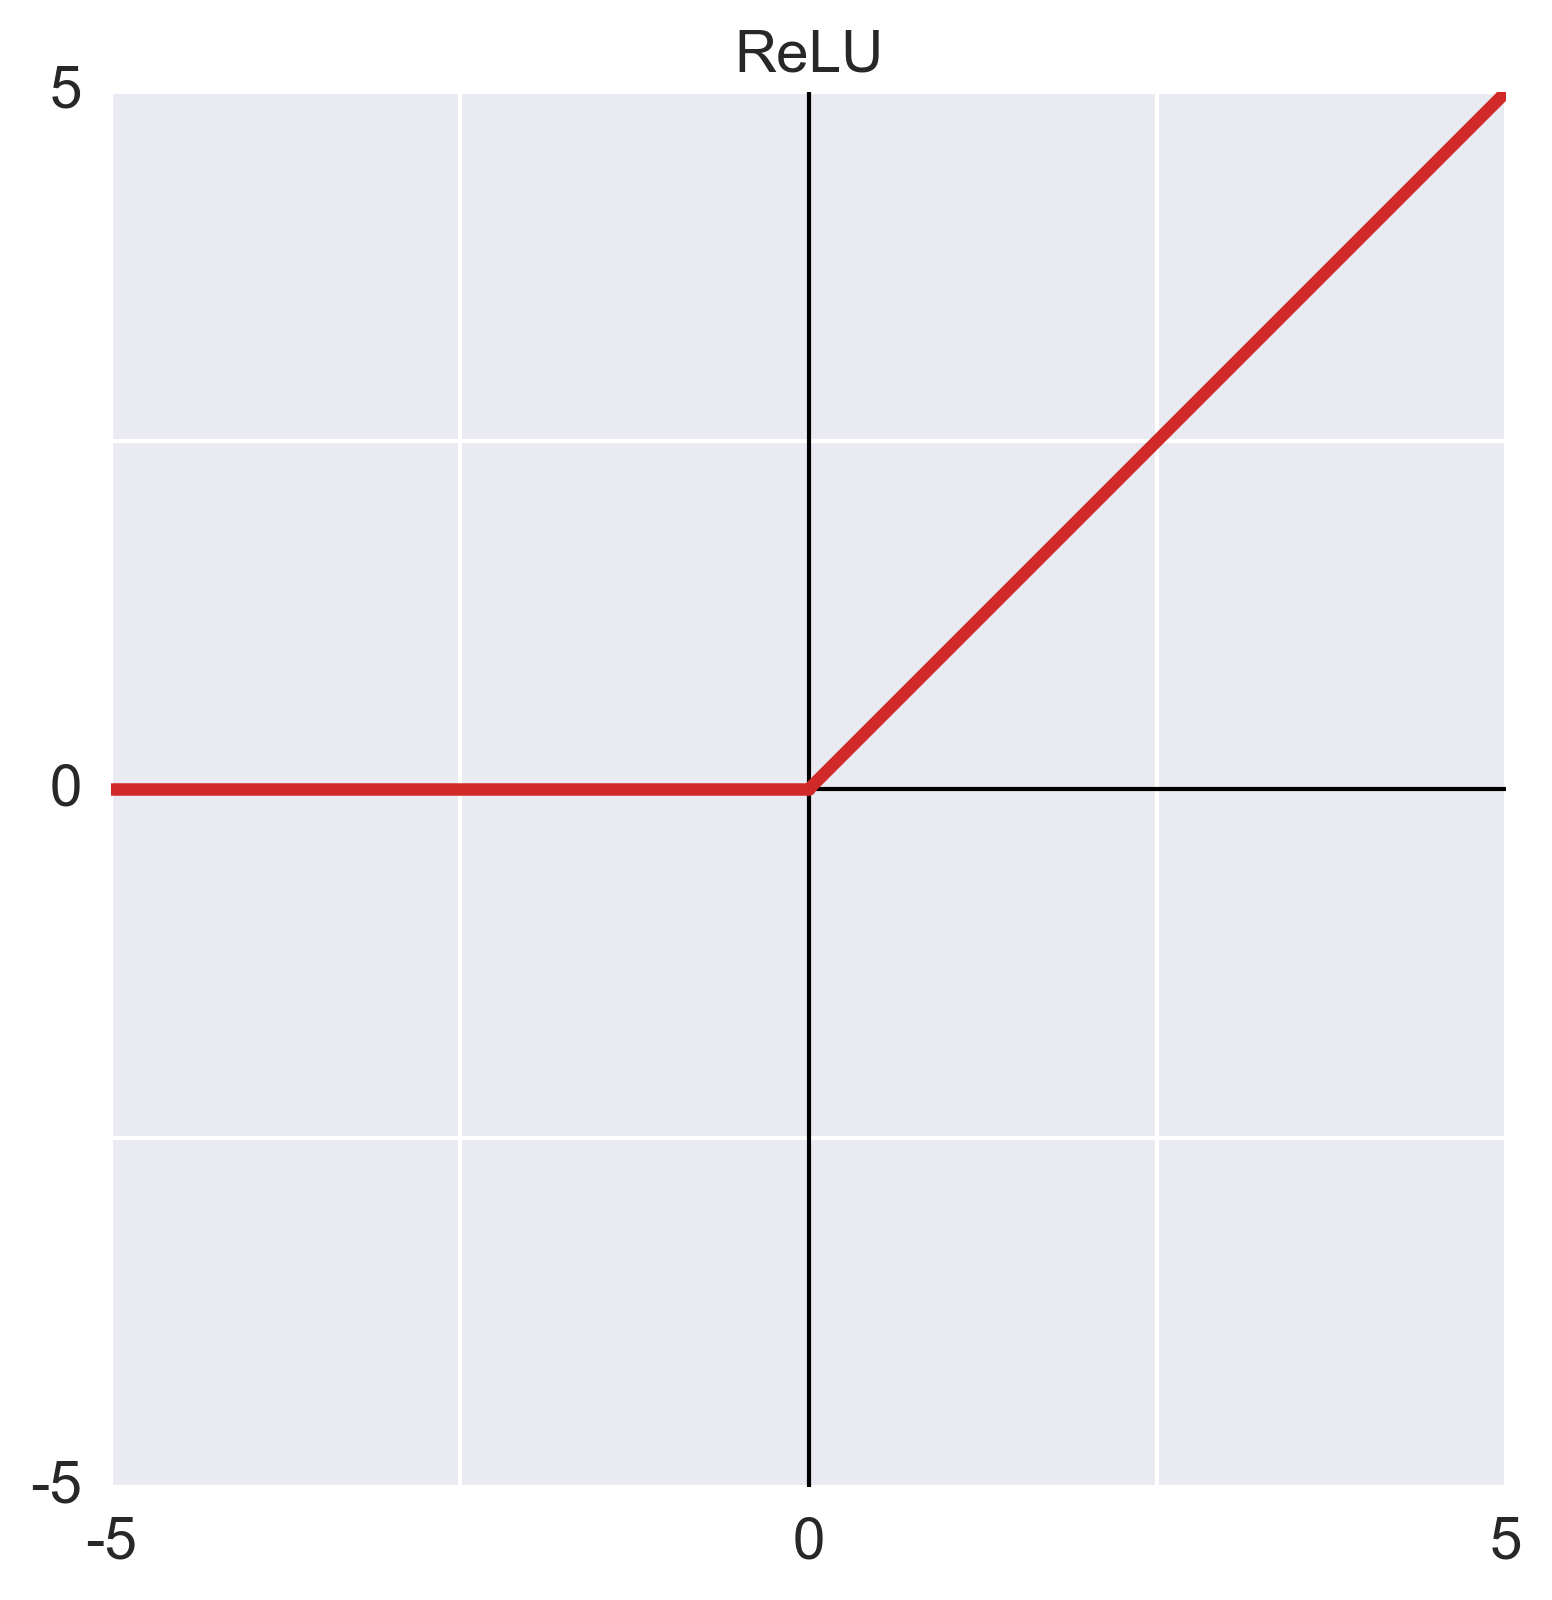

Below, we will implement RELU function. This function returns two items: the activation value `A` and a `cache` that contains `Z` (This will be used in later functions). To use it you could just call:

`A, activation_cache = relu(Z)`

HINT: To find the elelment-wise maximum of two arrays $A$ and $B$, you may use `np.maximum(A, B)`

In [ ]:
#Graded Activity 2
def relu(Z):
    """
    Implement the RELU function.
    Arguments:
    Z -- Output of the linear layer, of any shape
    Returns:
    A -- Post-activation parameter, of the same shape as Z
    cache -- a python dictionary containing "A" ; stored for computing the backward pass efficiently
    """
    #code the function, see https://numpy.org/doc/stable/reference/generated/numpy.maximum.html for np.maximum()
    A = np.maximum(0, Z)

    assert(A.shape == Z.shape)

    cache = Z
    return A, cache

## **2.2 Parameter Initialization**

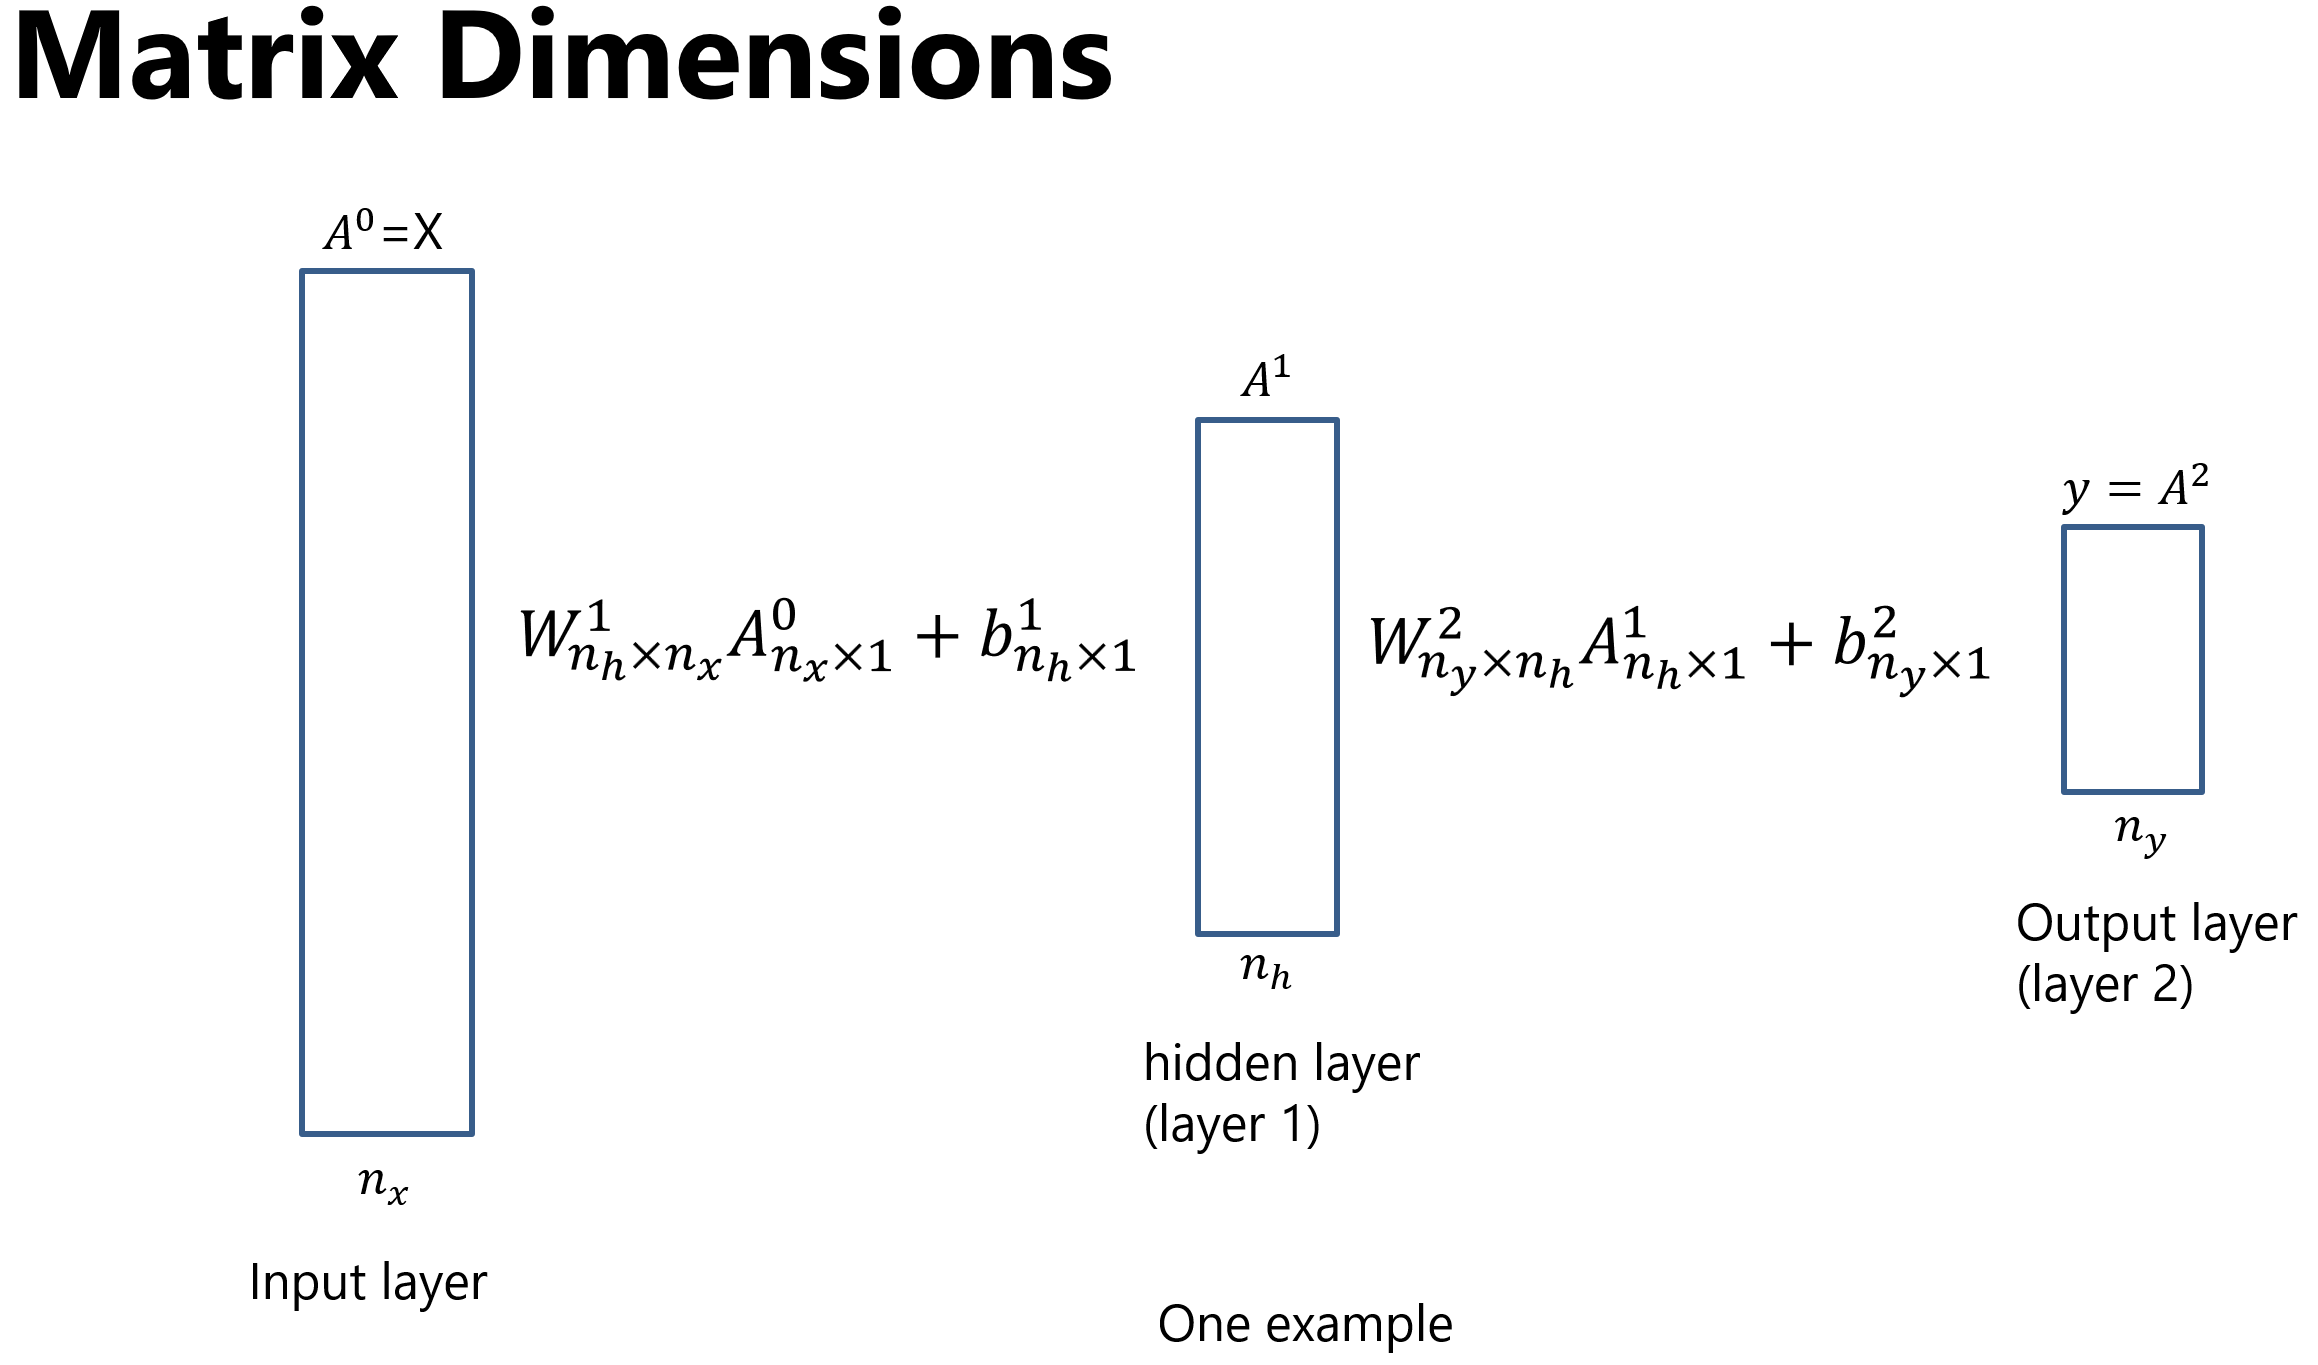

In this section, you will write a helper functions to initialize the parameters for your model. Remember, we are building a 2-layer neural network. The model's structure is: LINEAR -> RELU -> LINEAR -> SIGMOID. To train the neural network using backpropagation (+gradient descent), you have to initialize the variables for layer 1 ( `W1`, `b1`) and layer 2 (`W2` and `b2`). You can use random initialization for the weight matrices. Use `np.random.randn(shape)*0.01` with the correct shape. Use zero initialization for the biases. Use `np.zeros(shape)`. You have to figure out the appropriate shape. The above figures will help you in identifying the matrix dimensions (shape). Please use the next figure illustrating the forward propagation in conjunction with the above figure for a better understanding.

In [ ]:
#Graded Activity 3

# Initialize_parameters

def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer

    Returns:
    parameters -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """

    np.random.seed(1)

    #Initialize W1. np.random.randn(shape)*0.01. DO NOT just use 'shape', instead provide the correct shape of the matrices in terms of n_h, n_x, n_y, refer to https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html for the syntax of np.random.randn()
    W1 = np.random.randn(n_h, n_x) * 0.01
    #Initialize b1. HINT: np.zeros(shape), https://numpy.org/doc/stable/reference/generated/numpy.zeros.html
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    assert(W1.shape == (n_h, n_x))
    assert(b1.shape == (n_h, 1))
    assert(W2.shape == (n_y, n_h))
    assert(b2.shape == (n_y, 1))

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters

In [ ]:
parameters = initialize_parameters(3,2,1)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.01624345 -0.00611756 -0.00528172]
 [-0.01072969  0.00865408 -0.02301539]]
b1 = [[0.]
 [0.]]
W2 = [[ 0.01744812 -0.00761207]]
b2 = [[0.]]


## **2.3 Forward Propagation**

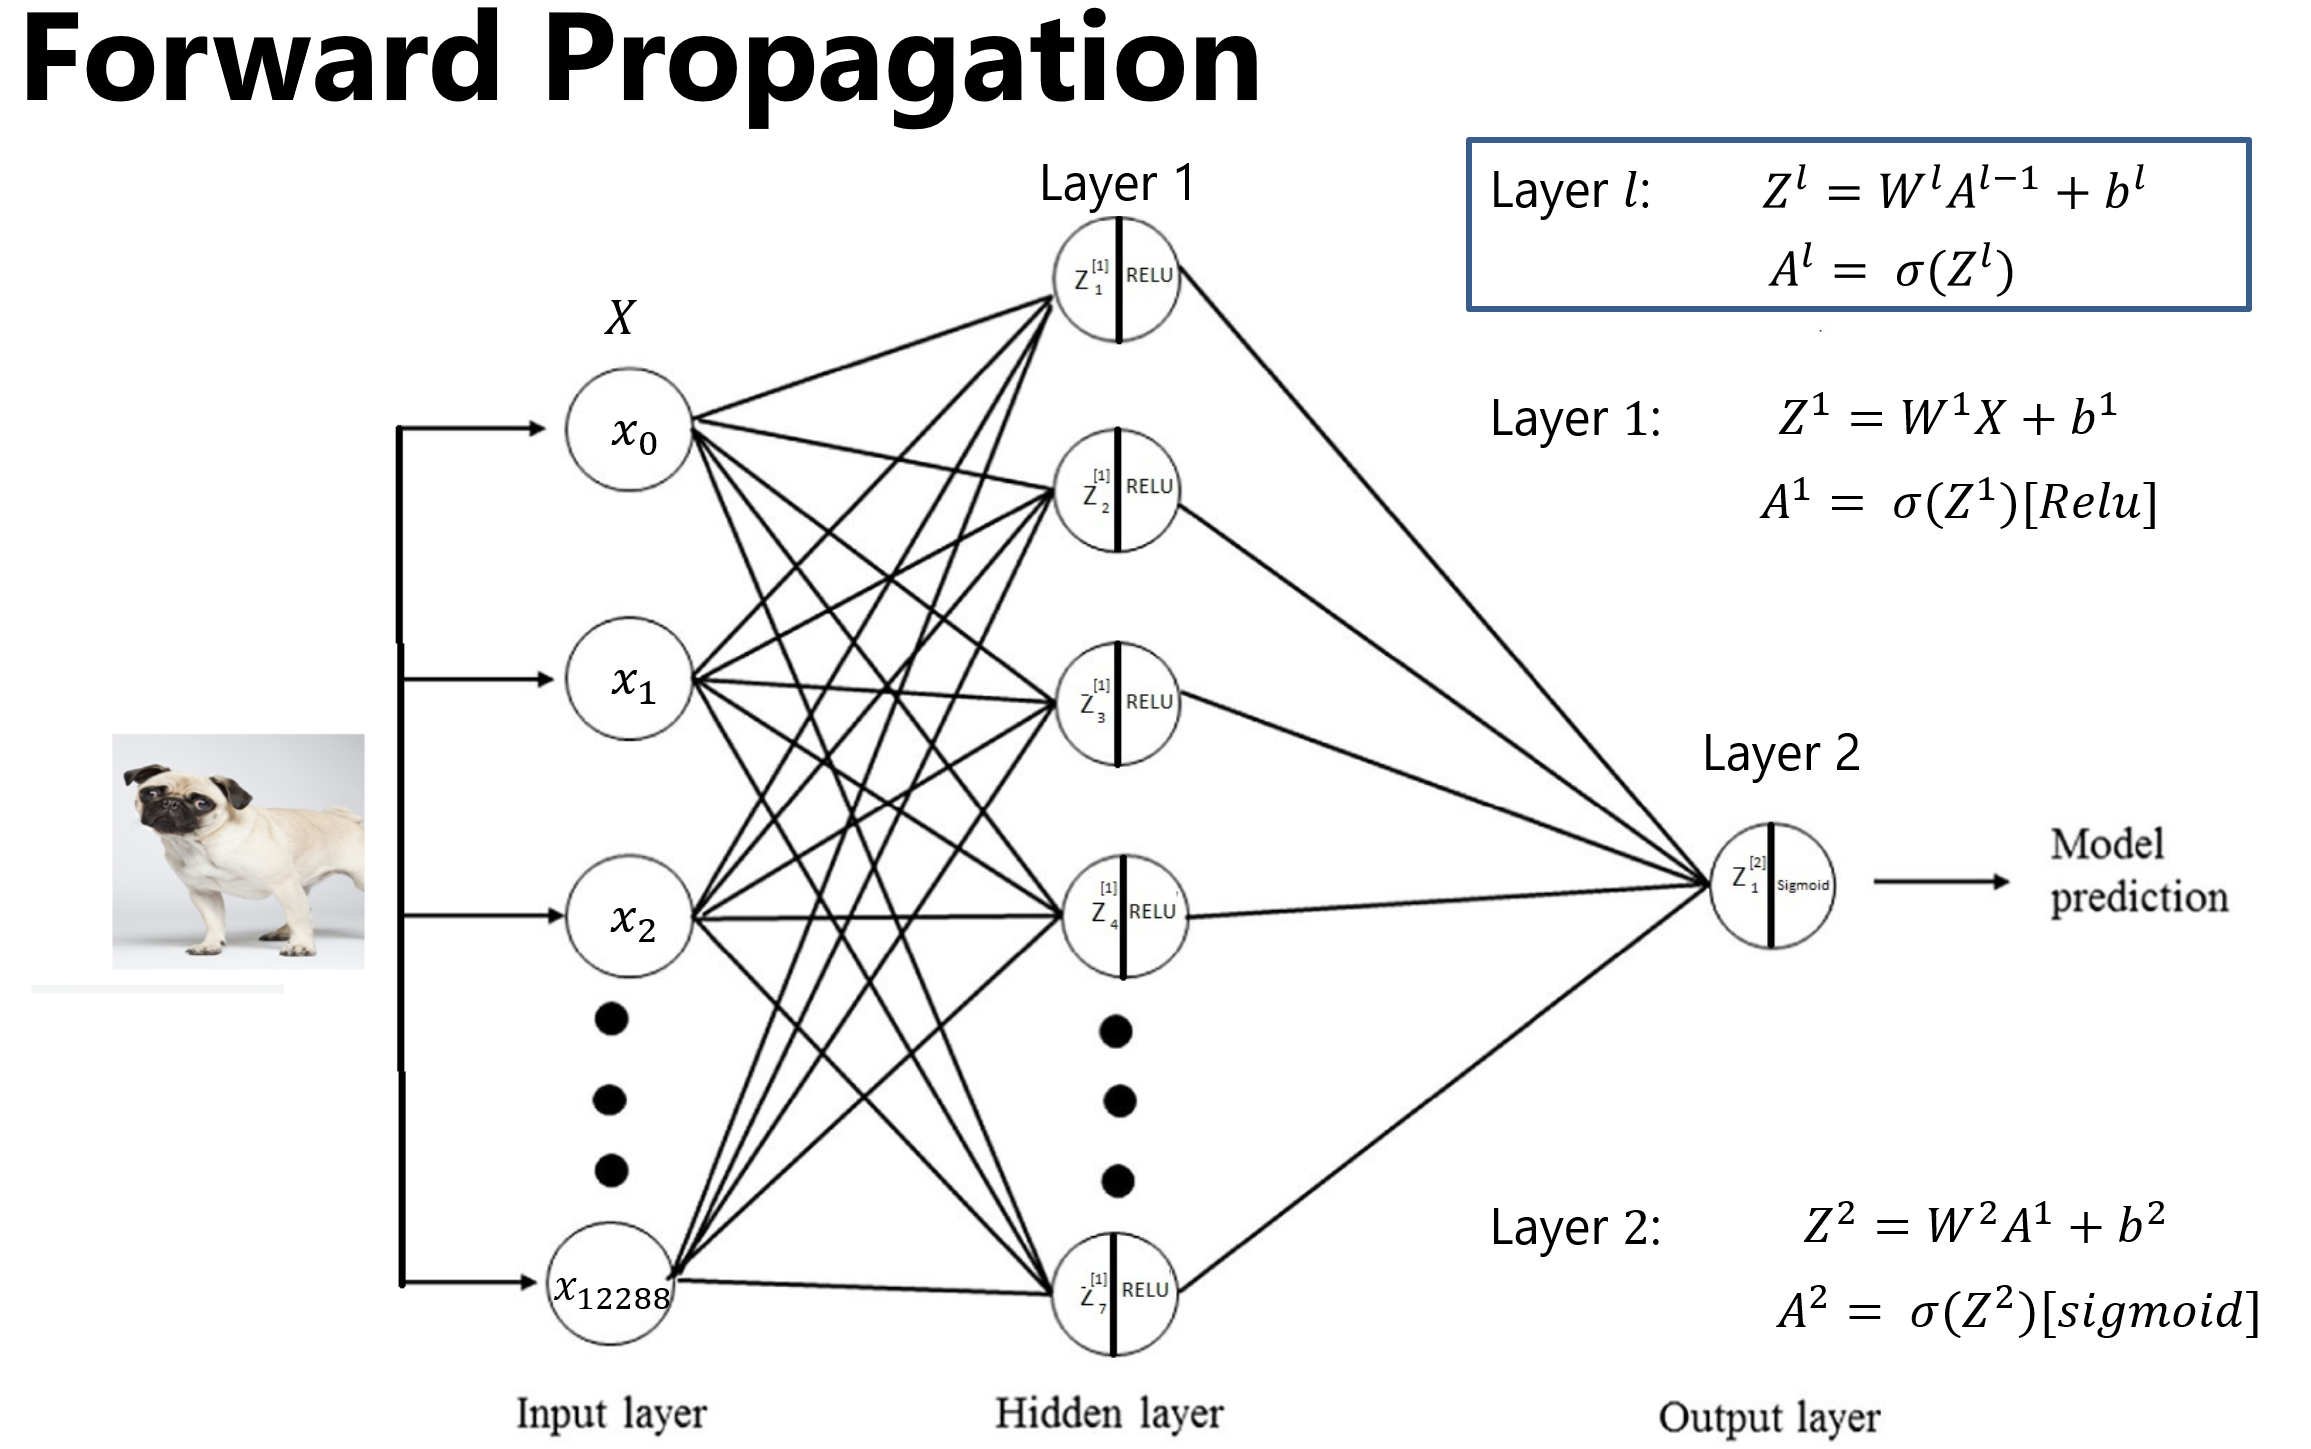

Now that you have initialized your parameters, you can proceed to the forward propagation module. You will start by implementing some basic functions that you will use later when implementing the model. Your task is to complete three functions in this order:

* LINEAR
* LINEAR -> ACTIVATION where ACTIVATION will be either ReLU or Sigmoid.
* [LINEAR -> RELU]  (L-1) -> LINEAR -> SIGMOID (whole model).

In forward propagation, every nodes in layer $l$ in the network depends on the output of the nodes in the previous layer $l-1$.  So, the linear forward module (vectorized over all the examples) computes the following equations:

$ Z ^ {[l]} = W ^ {[l]} A ^ {[l - 1]} + b ^ {[l]} $

where $ A ^ {[0]} = X $
.

Your task is to implement the linear part of forward propagation.

Reminder: The mathematical representation of this unit is  $ Z ^ {[l]} = W ^ {[l]} A ^ {[l - 1]} + b ^ {[l]} $. You may find `np.dot()` useful.  To multiply two matrices $A$ and $B$, you may just call $np.dot(A, B)$. If your dimensions do not match, printing `W.shape` may help. Other useful commands for matrix multiplication include $np.matmul()$ and $@$ (e.g., $A @ B$).

In [ ]:
# Graded Activity 4

def linear_forward(A, W, b):
    """
    Implement the linear part of a layer's forward propagation.

    Arguments:
    A -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)

    Returns:
    Z -- the input of the activation function, also called pre-activation parameter
    cache -- a python dictionary containing "A", "W" and "b" ; stored for computing the backward pass efficiently
    """

    #use appropriate function to compute Z, np.dot()/ @
    Z = np.dot(W, A) + b


    assert(Z.shape == (W.shape[0], A.shape[1]))
    cache = (A, W, b)

    return Z, cache

In [ ]:
A, W, b = linear_forward_test_case()

Z, linear_cache = linear_forward(A, W, b)
print("Z = " + str(Z))

Z = [[ 3.26295337 -1.23429987]]


For more convenience, you are going to group two functions (Linear and Activation) into one function (LINEAR->ACTIVATION). Hence, you will implement a function that does the LINEAR forward step followed by an ACTIVATION forward step.


Implement the forward propagation of the LINEAR->ACTIVATION layer. Mathematical relation is: $ 𝛔(Z)$  where the activation $𝛔$ can be sigmoid() or relu(). Use linear_forward() and the correct activation function.

In [ ]:
# Graded Activity 5

def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer

    Arguments:
    A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

    Returns:
    A -- the output of the activation function, also called the post-activation value
    cache -- a python dictionary containing "linear_cache" and "activation_cache";
             stored for computing the backward pass efficiently
    """

    if activation == "sigmoid":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache". Use linear_forward() function
        Z, linear_cache = linear_forward(A_prev, W, b)
        #Use the appropriate activation function
        A, activation_cache = sigmoid(Z)


    elif activation == "relu":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache". Use linear_forward() function
        Z, linear_cache = linear_forward(A_prev, W, b)
        #Use the appropriate activation function
        A, activation_cache = relu(Z)


    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

In [ ]:
A_prev, W, b = linear_activation_forward_test_case()

A, linear_activation_cache = linear_activation_forward(A_prev, W, b, activation = "sigmoid")
print("With sigmoid: A = " + str(A))

A, linear_activation_cache = linear_activation_forward(A_prev, W, b, activation = "relu")
print("With ReLU: A = " + str(A))

With sigmoid: A = [[0.96890023 0.11013289]]
With ReLU: A = [[3.43896131 0.        ]]


## **2.4 Cost Function**

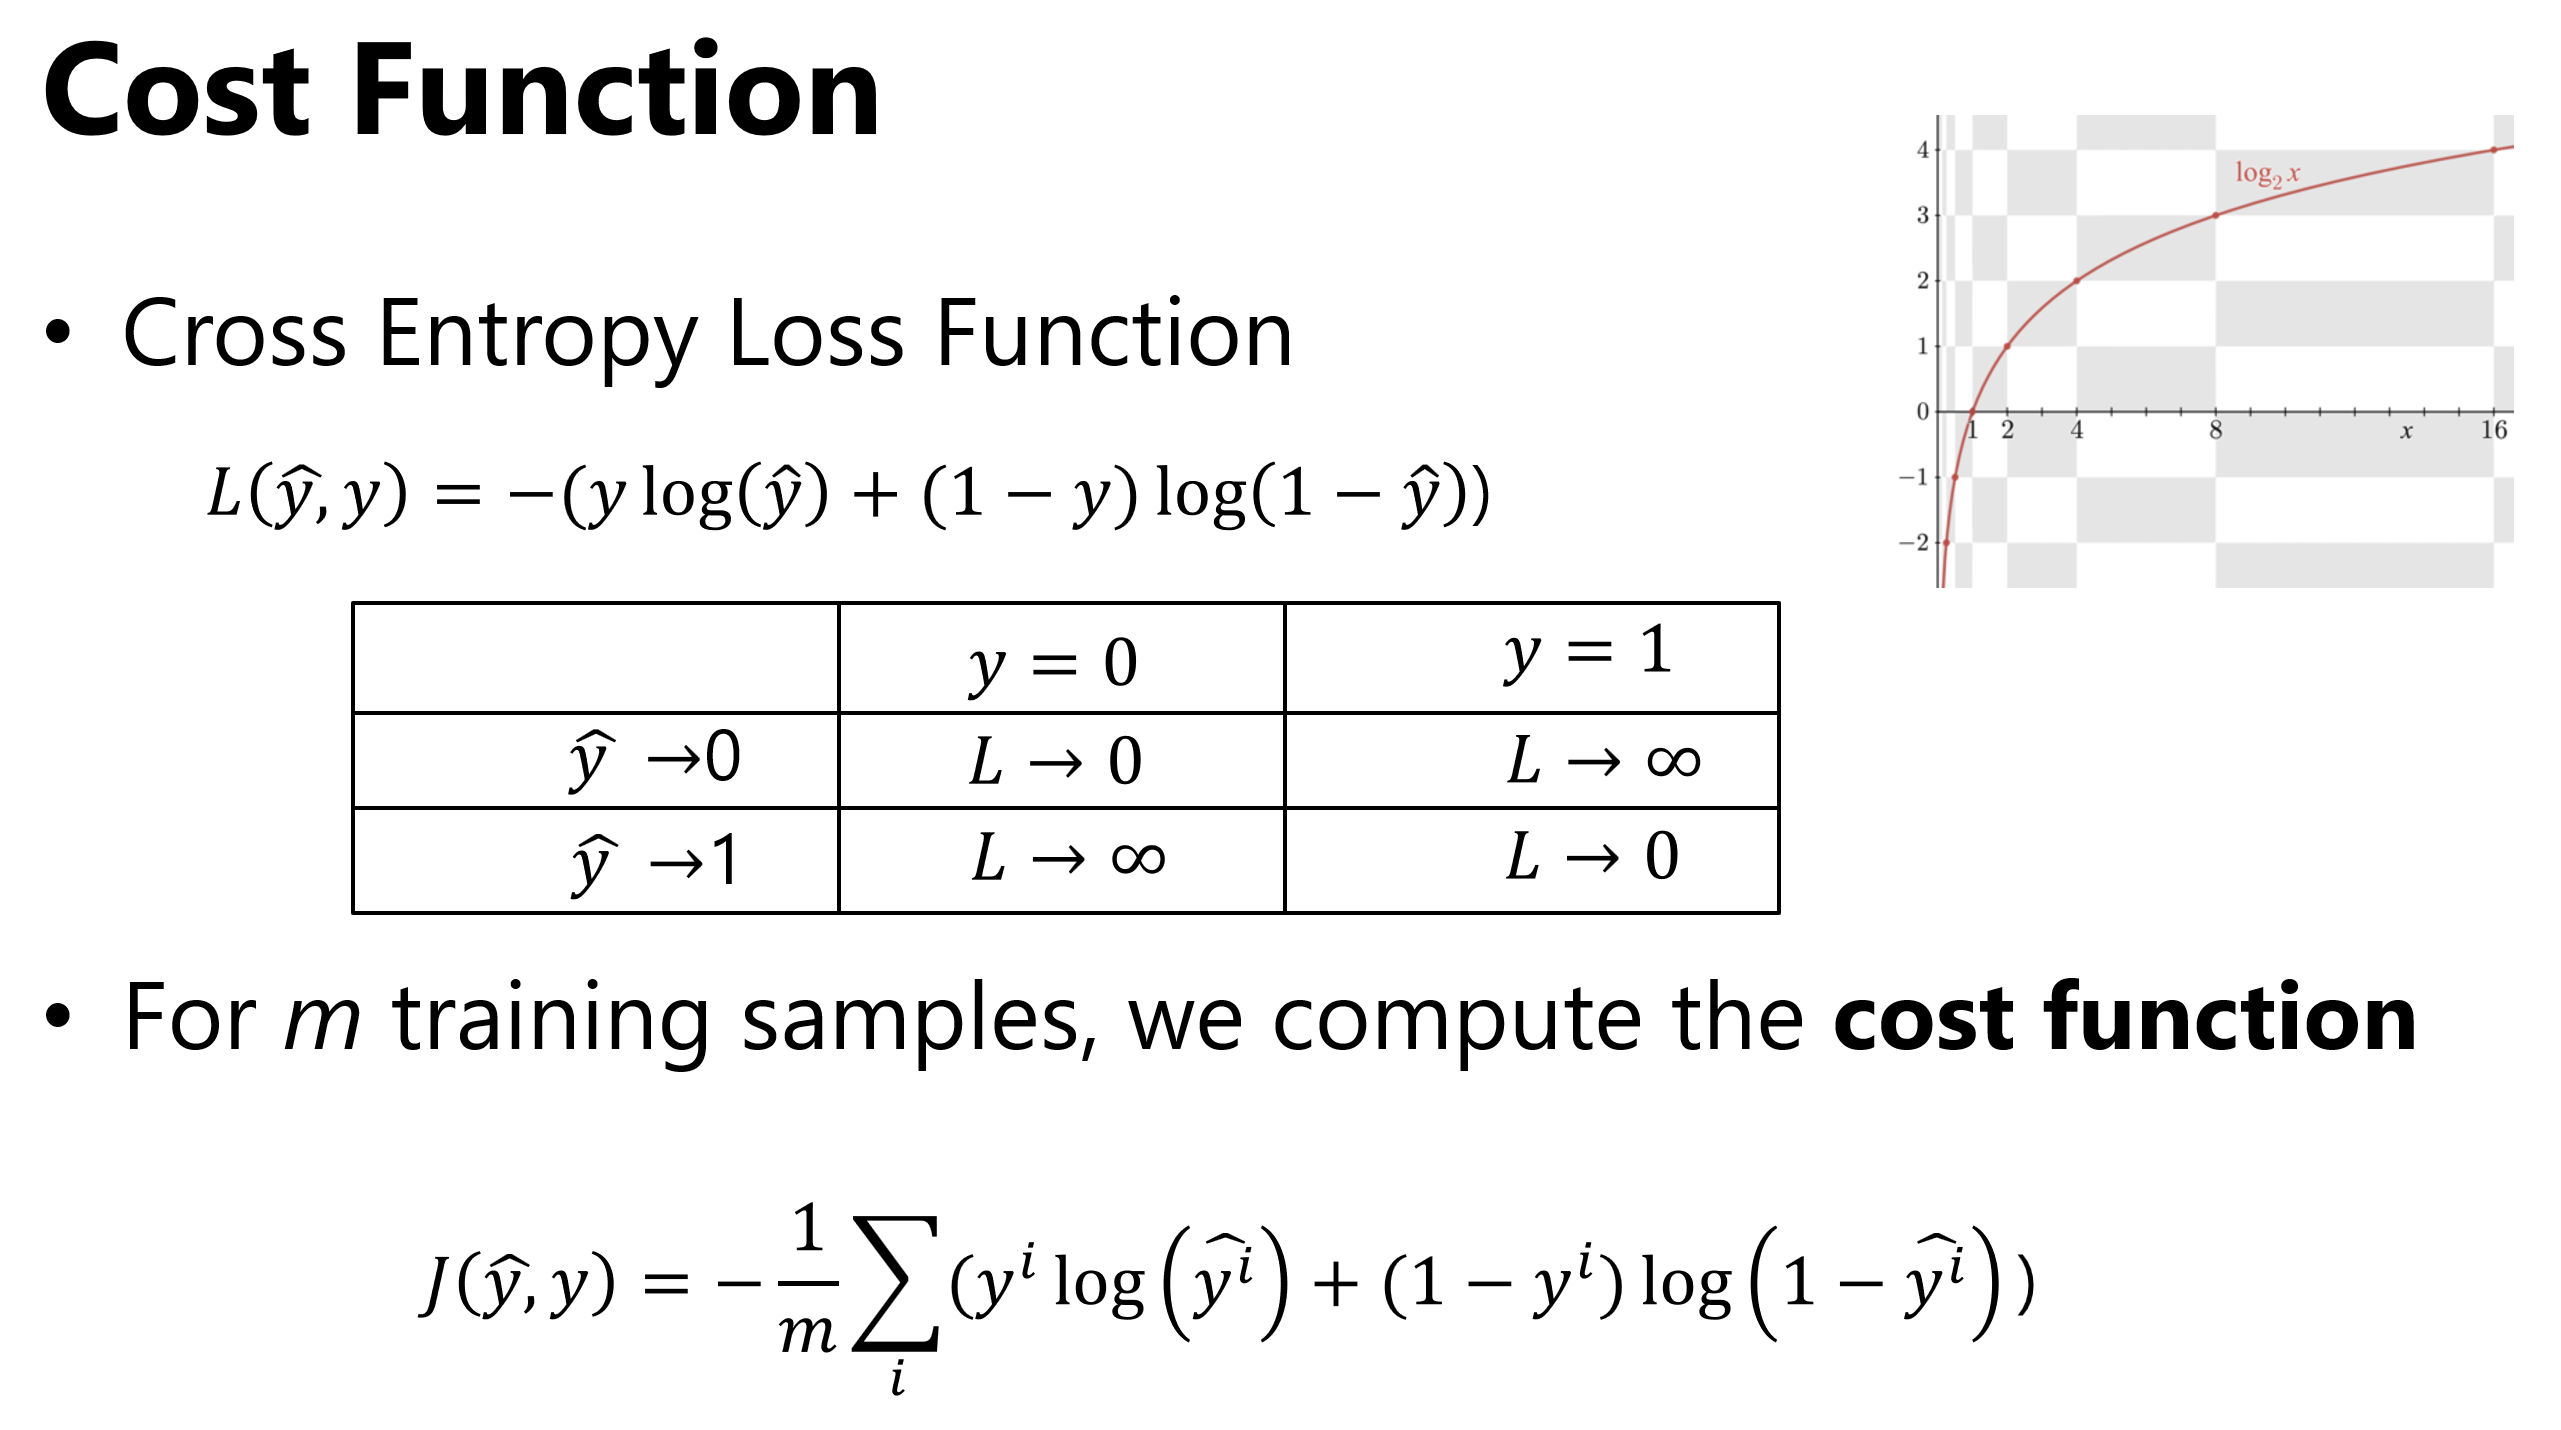

To check if your model is actually learning, you have to compute the cost. We will use cross-entropy cost in this assignment (refer to Lecture 8 slide above, we use $a^L$ instead of $\hat{y}$ in the equation).

Compute the cross-entropy cost $ J $ , using the following formula: $ {-1/m \sum_{i=1}^m (y ^ {(i)}\log(a ^ {[L]i}) + (1 - y ^ {(i)})\log(1 - a ^ {[L]i}))}$


In [ ]:
# Graded Activity 6

def compute_cost(AL, Y):
    """
    Implement the cost function.

    Parameters:
    AL -- probability vector corresponding to your label predictions, shape (1, number of examples)
    Y -- true "label" vector (for example: containing 0 if non-cat, 1 if cat), shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost
    """

    m = Y.shape[1]

    # Compute loss from aL and y. Implement the above firmula for J. You may find np.log(), np.sum() useful.
    cost = -1/m * np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))


    # To make sure your cost's shape is what we expect (e.g. this turns [[17]] into 17), see https://numpy.org/doc/stable/reference/generated/numpy.squeeze.html.
    cost = np.squeeze(cost)
    # Checking whether cost is a scalar value
    assert(cost.shape == ())

    return cost

In [ ]:
Y, AL = compute_cost_test_case()

print("cost = " + str(compute_cost(AL, Y)))

cost = 0.41493159961539694


Expected Output:

**cost**	0.41493159961539694


## **2.5 Backward Propagation**

Just like with forward propagation, you will implement helper functions for backpropagation. Remember that back propagation is used to calculate the gradient of the loss function with respect to the parameters, $W$ and $b$.

Now, similar to forward propagation, you are going to build the backward propagation using the following steps:

* LINEAR backward
* LINEAR -> ACTIVATION backward where ACTIVATION computes the derivative of either the ReLU or sigmoid activation.


**Linear backward:**

For layer $ l $ , the linear part is: $ Z ^ {[l]} = W ^ {[l]} A ^ {[l - 1]} + b ^ {[l]} $
 (followed by an activation).

Suppose you have already calculated the derivative $ dZ ^ {[l]} = {\partial L} / {\partial Z ^ {[l]}}  $. You want to get  
$dW ^ {[l]}, dA ^ {[l - 1]}, db ^ {[l]}   $.

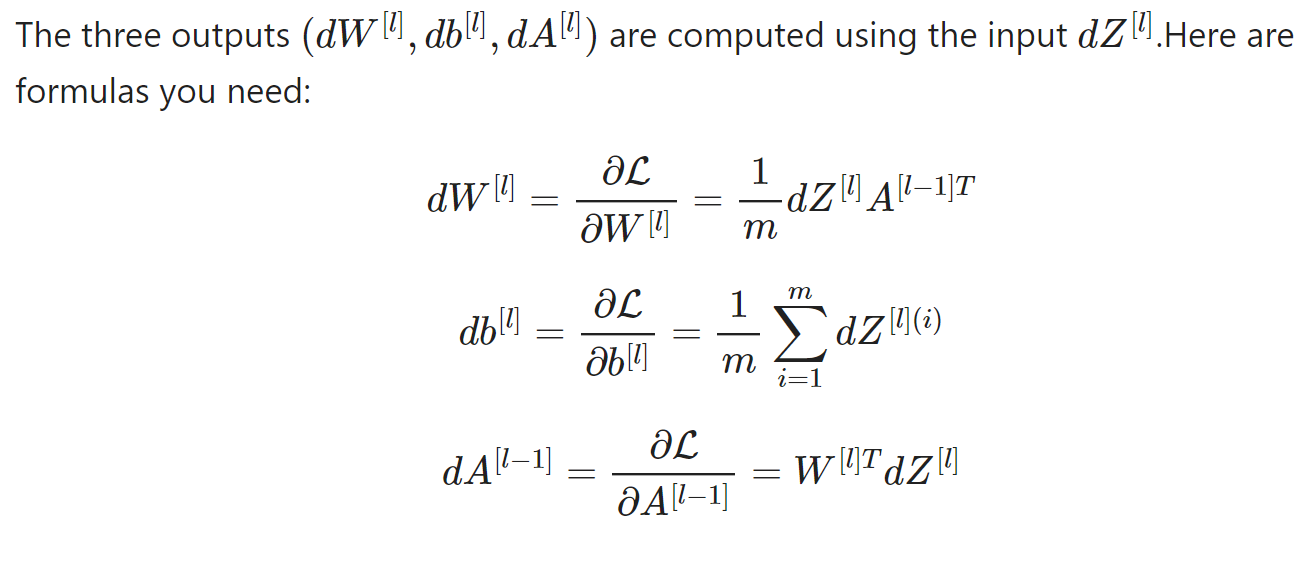

Please find below an example of how you get the above formulae (discussed in the lecture).

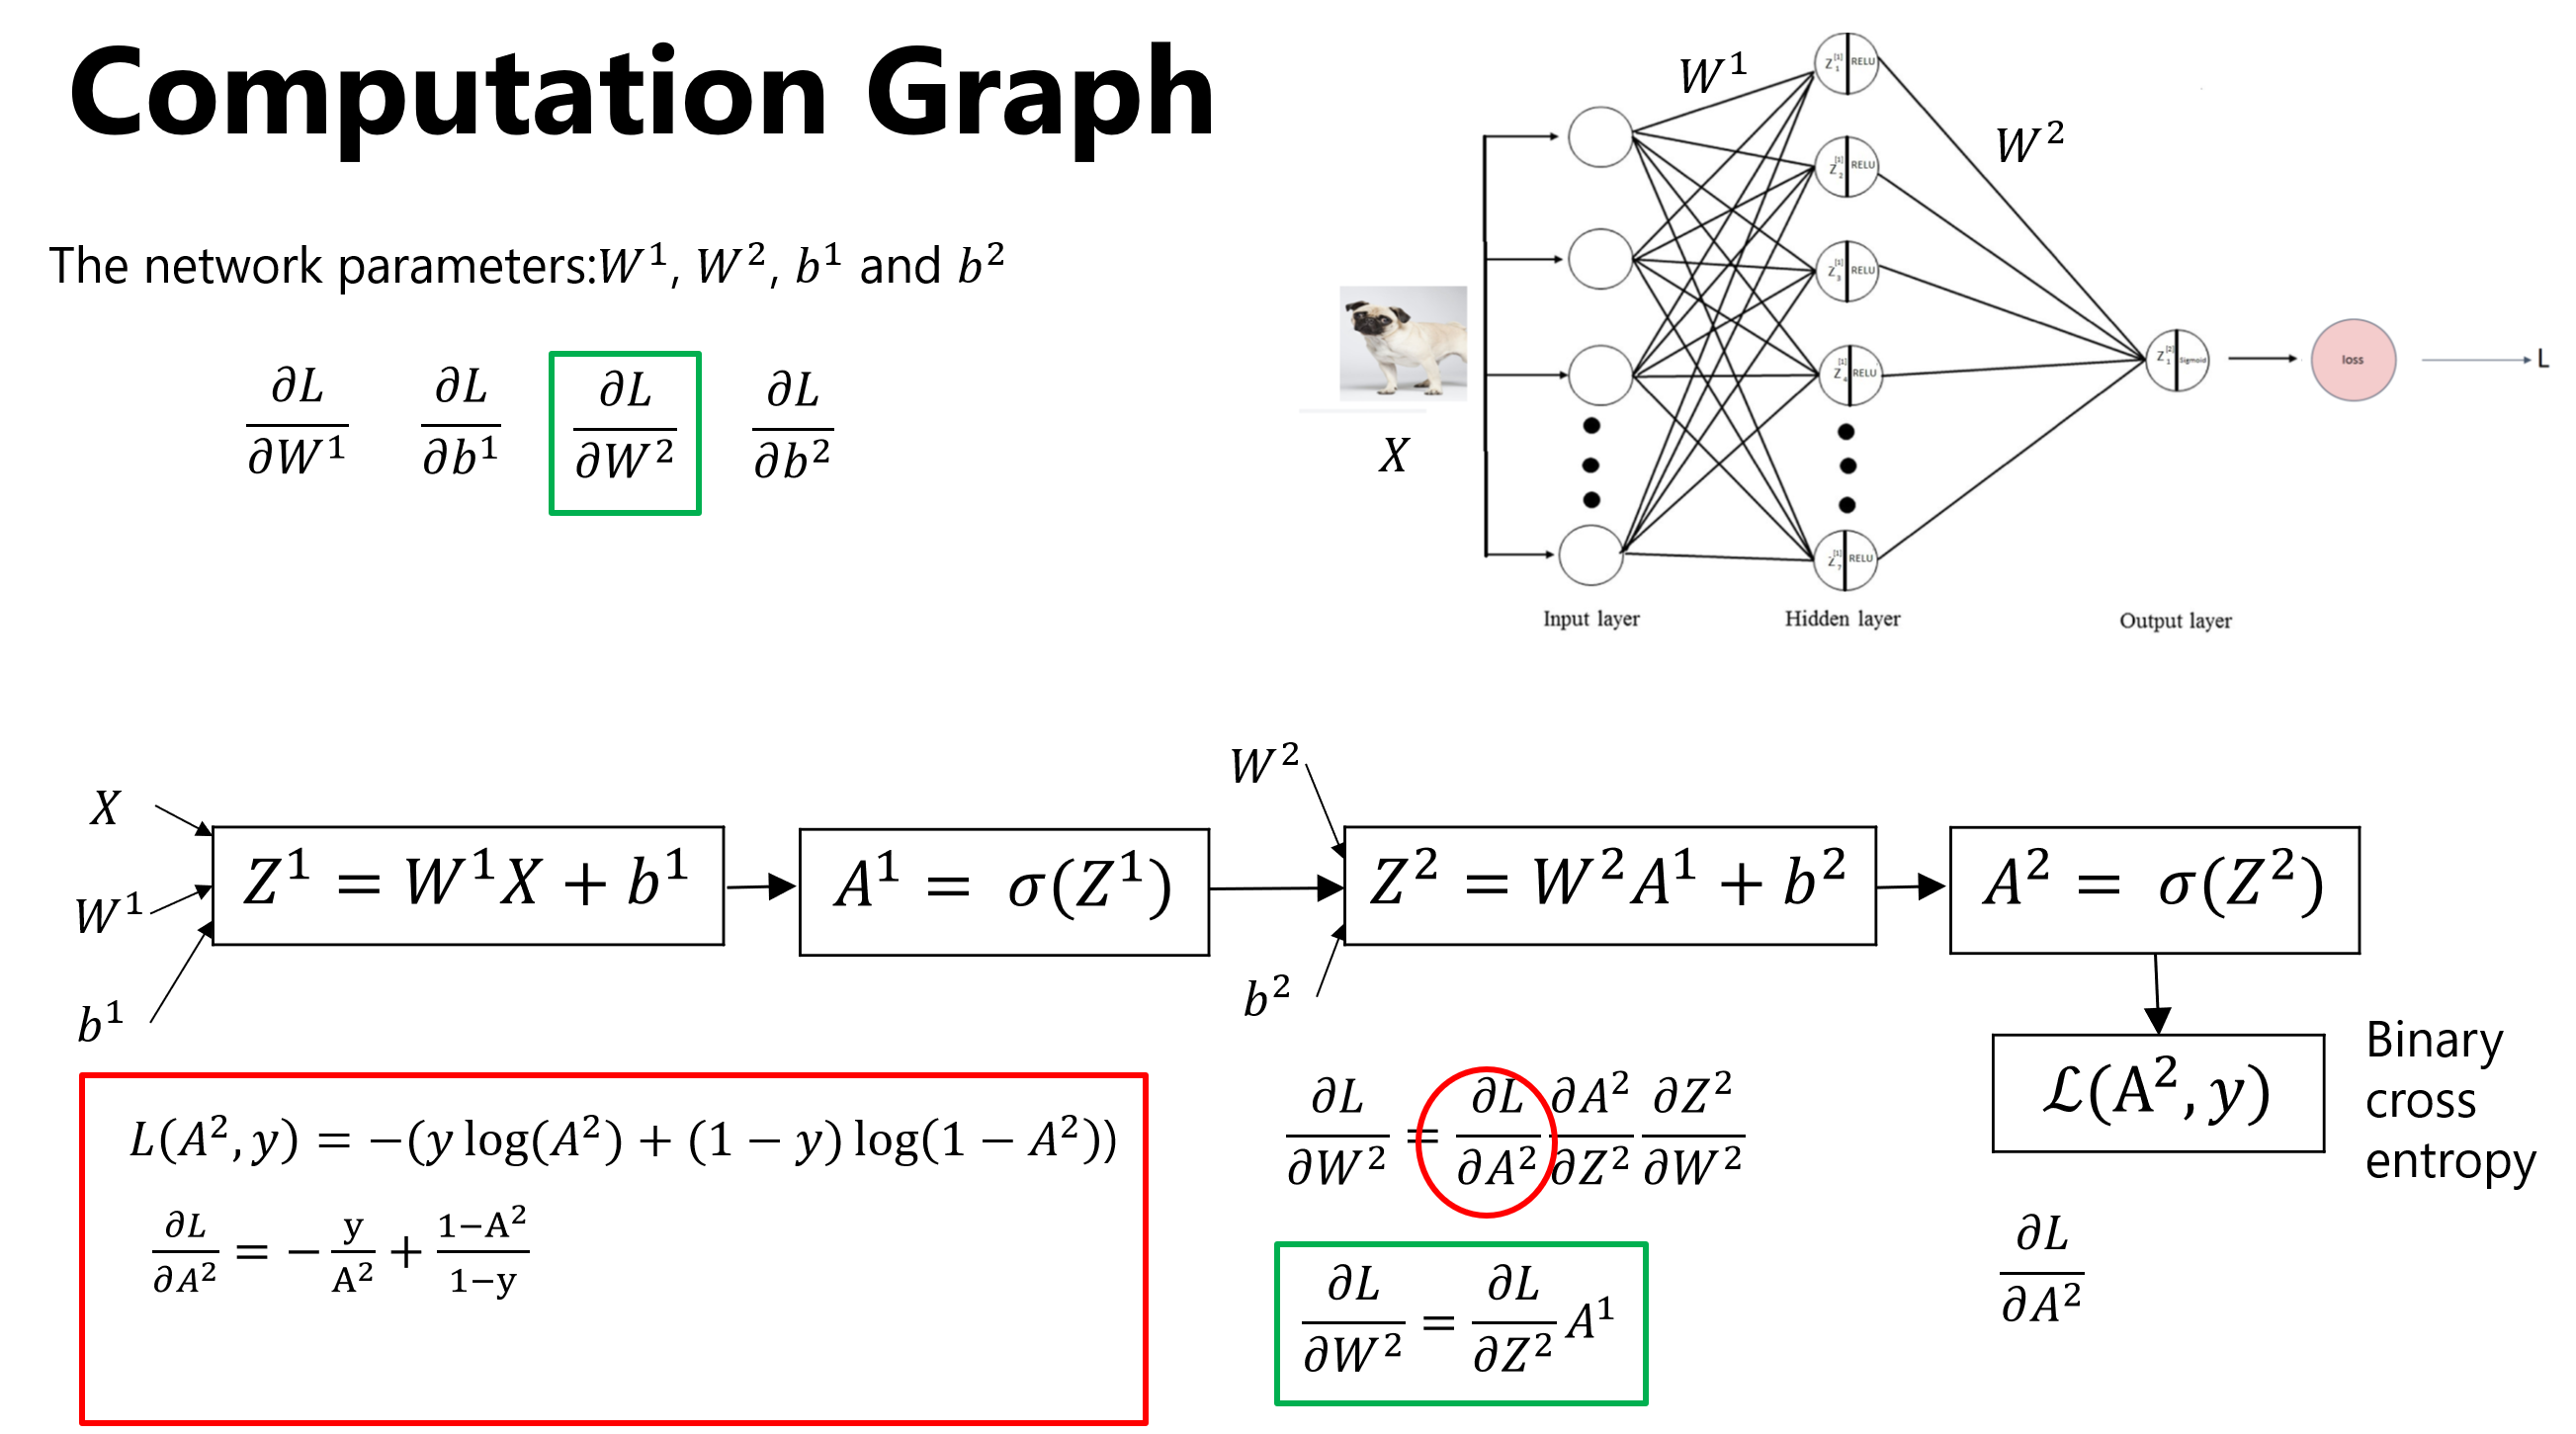

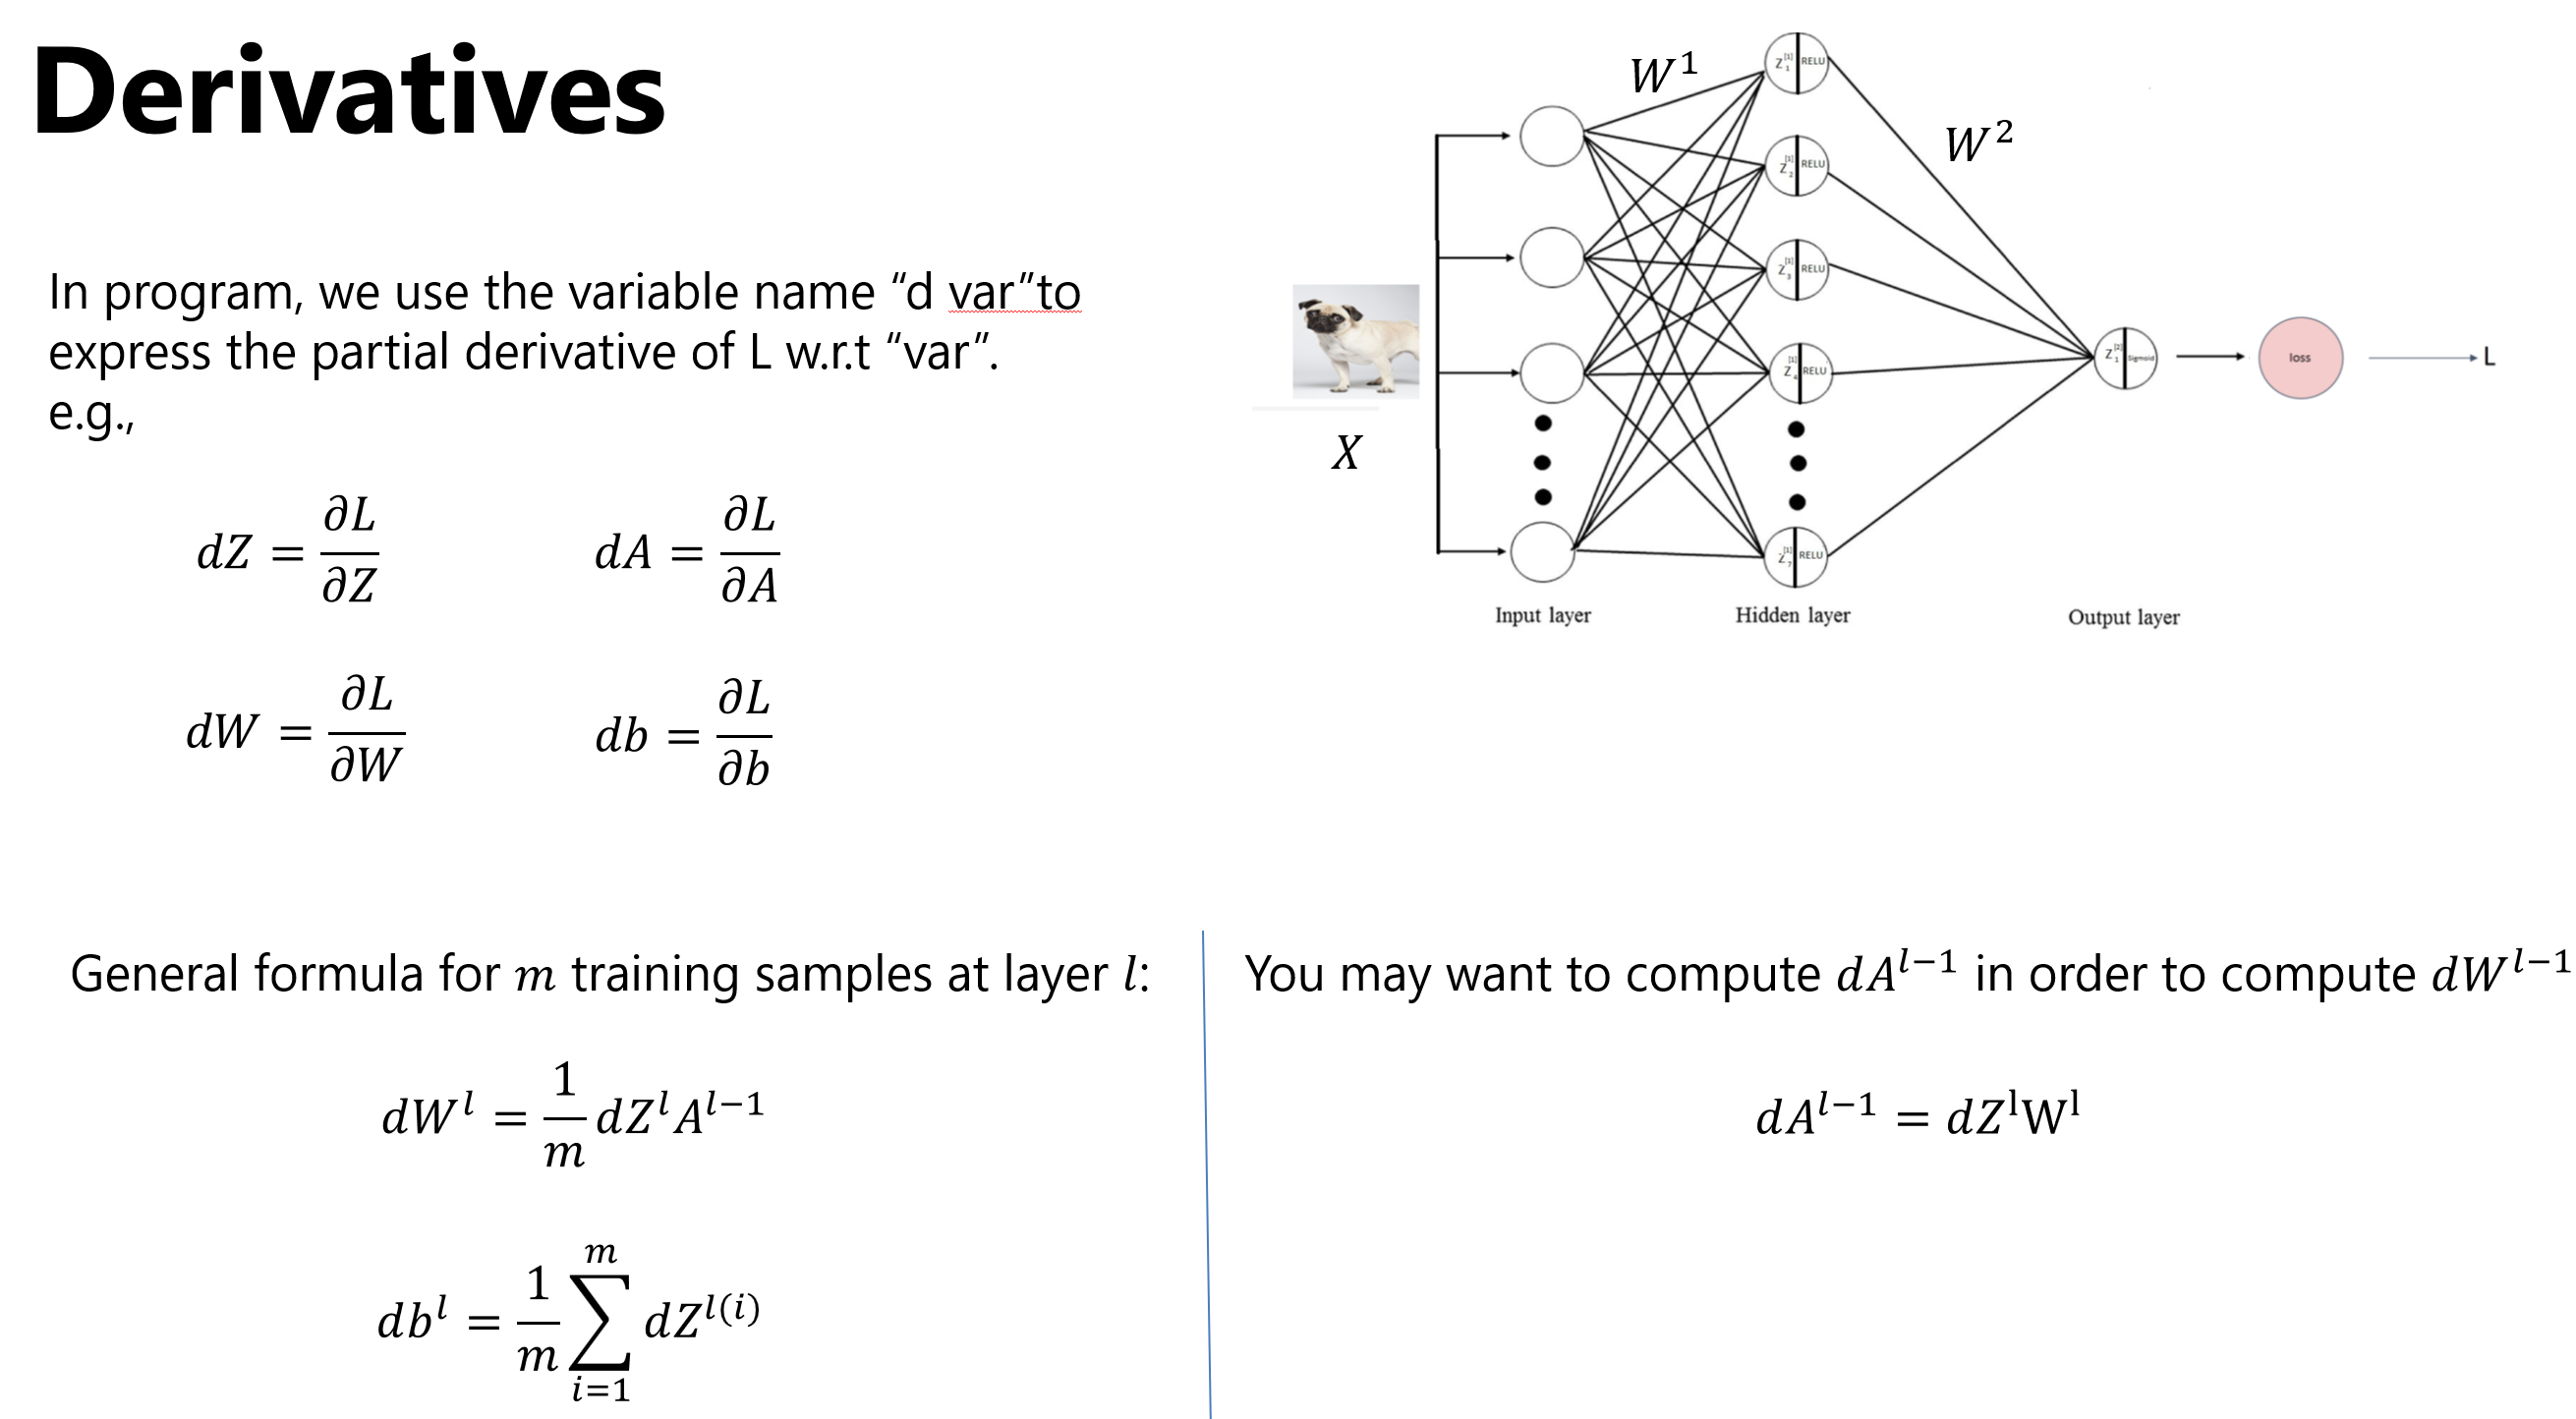

You can use the above formulae to implement `linear_backward()`.





In [ ]:
# Graded Activity 7

def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    A_prev, W, b = cache
    m = A_prev.shape[1]

    #Compute dW. You may use np.dot() function or @ operator. Make sure to consider m samples, i.e., 1/m. Other inputs would be A_prev and dZ, see the above equations.
    dW = (1/m) * np.dot(dZ, A_prev.T)

    # np.sum(dZ, axis=1, keepdims=True) may be useful to compute the sum of dZ
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

    # W and dZ. However, you may want to use the transpose of one of the inputs to make the dimensions compatible for the multiplication.
    dA_prev = np.dot(W.T, dZ)


    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)

    return dA_prev, dW, db

In [ ]:
# Set up some test inputs
dZ, linear_cache = linear_backward_test_case()

dA_prev, dW, db = linear_backward(dZ, linear_cache)
print ("dA_prev = "+ str(dA_prev))
print ("dW = " + str(dW))
print ("db = " + str(db))

dA_prev = [[ 0.51822968 -0.19517421]
 [-0.40506361  0.15255393]
 [ 2.37496825 -0.89445391]]
dW = [[-0.10076895  1.40685096  1.64992505]]
db = [[0.50629448]]


**Linear-Activation backward:**

Next, you will create a function that merges the two helper functions: linear_backward and the backward step for the activation linear_activation_backward.

To help you implement linear_activation_backward, we provided two backward functions:

**sigmoid_backward:** Implements the backward propagation for SIGMOID unit. You can call it as follows:

`dZ = sigmoid_backward(dA, activation_cache)`

**relu_backward:** Implements the backward propagation for RELU unit. You can call it as follows:

`dZ = relu_backward(dA, activation_cache)`

Depending on the activation used in a layer, `sigmoid_backward` and `relu_backward` can be used.  

Implement the backpropagation for the LINEAR->ACTIVATION layer.

In [ ]:
# Graded Activity 8

def linear_activation_backward(dA, cache, activation):
    """
    Implement the backward propagation for the LINEAR->ACTIVATION layer.

    Arguments:
    dA -- post-activation gradient for current layer l
    cache -- tuple of values (linear_cache, activation_cache) we store for computing backward propagation efficiently
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    linear_cache, activation_cache = cache

    if activation == "relu":
        # call relu_backward() with dA and activation cache as the arguments
        dZ = relu_backward(dA, activation_cache)
        #call linear_backward() with appropriate arguments
        dA_prev, dW, db = linear_backward(dZ, linear_cache)


    elif activation == "sigmoid":
        # call sigmoid_backward() with dA and activation cache as the arguments
        dZ = sigmoid_backward(dA, activation_cache)
        #call linear_backward() with appropriate arguments
        dA_prev, dW, db = linear_backward(dZ, linear_cache)


    return dA_prev, dW, db

In [ ]:
dAL, linear_activation_cache = linear_activation_backward_test_case()

dA_prev, dW, db = linear_activation_backward(dAL, linear_activation_cache, activation = "sigmoid")
print ("sigmoid:")
print ("dA_prev = "+ str(dA_prev))
print ("dW = " + str(dW))
print ("db = " + str(db) + "\n")

dA_prev, dW, db = linear_activation_backward(dAL, linear_activation_cache, activation = "relu")
print ("relu:")
print ("dA_prev = "+ str(dA_prev))
print ("dW = " + str(dW))
print ("db = " + str(db))

sigmoid:
dA_prev = [[ 0.11017994  0.01105339]
 [ 0.09466817  0.00949723]
 [-0.05743092 -0.00576154]]
dW = [[ 0.10266786  0.09778551 -0.01968084]]
db = [[-0.05729622]]

relu:
dA_prev = [[ 0.44090989  0.        ]
 [ 0.37883606  0.        ]
 [-0.2298228   0.        ]]
dW = [[ 0.44513824  0.37371418 -0.10478989]]
db = [[-0.20837892]]


**Update Parameters:**

In this section you will update the parameters of the model, using gradient descent as follows.

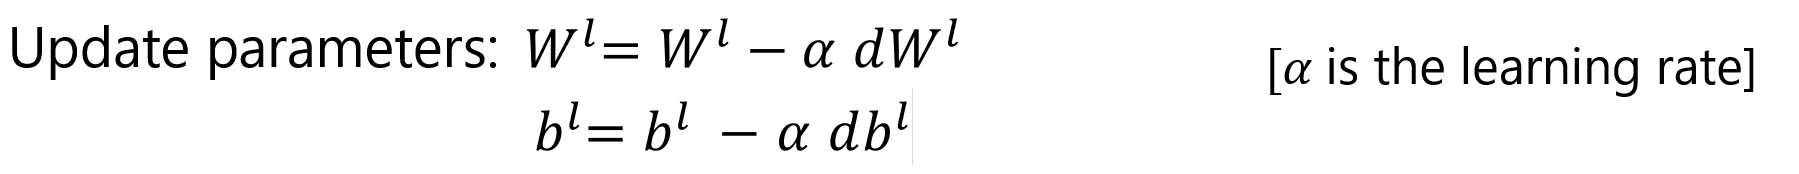

After computing the updated parameters, store them in the parameters dictionary.

Your next task is to complete the `update_parameters()` function to update your parameters using gradient descent.

In [ ]:
# Graded Activity 9

def update_parameters(parameters, grads, learning_rate):
    """
    Update parameters using gradient descent

    Arguments:
    parameters -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients, output of L_model_backward

    Returns:
    parameters -- python dictionary containing your updated parameters
                  parameters["W" + str(l)] = ...
                  parameters["b" + str(l)] = ...
    """

    L = len(parameters) // 2 # number of layers in the neural network

    # Update rule for each parameter. Use a for loop.

    for l in range(L):
        # Use appropriate parameters["W"+__], learning_rate  and  grads["dW"+___] for the update. Dictionary access is already shown below.
        parameters["W" + str(l+1)] -= learning_rate * grads["dW" + str(l + 1)]
        # Use appropriate parameters["b"+__], learning_rate  and  grads["db"+___] for the update.
        parameters["b" + str(l+1)] -= learning_rate * grads["db" + str(l + 1)]

    return parameters

In [ ]:
parameters, grads = update_parameters_test_case()
parameters = update_parameters(parameters, grads, 0.1)
print ("W1 = "+ str(parameters["W1"]))
print ("b1 = "+ str(parameters["b1"]))
print ("W2 = "+ str(parameters["W2"]))
print ("b2 = "+ str(parameters["b2"]))

W1 = [[-0.59562069 -0.09991781 -2.14584584  1.82662008]
 [-1.76569676 -0.80627147  0.51115557 -1.18258802]
 [-1.0535704  -0.86128581  0.68284052  2.20374577]]
b1 = [[-0.04659241]
 [-1.28888275]
 [ 0.53405496]]
W2 = [[-0.55569196  0.0354055   1.32964895]]
b2 = [[-0.84610769]]


Expected output:
    W1 = [[-0.59562069 -0.09991781 -2.14584584  1.82662008]
 [-1.76569676 -0.80627147  0.51115557 -1.18258802]
 [-1.0535704  -0.86128581  0.68284052  2.20374577]]
b1 = [[-0.04659241]
 [-1.28888275]
 [ 0.53405496]]
W2 = [[-0.55569196  0.0354055   1.32964895]]
b2 = [[-0.84610769]]

# **4. Build the Final Model**

General algorithm for building the model:
1. Initialize parameters
2. Loop for num_iterations(see the Figure below):

    a. Forward propagation

    b. Compute cost function

    c. Backward propagation
    
    d. Update parameters (using parameters, and grads from backprop)
4. Use trained parameters to predict labels

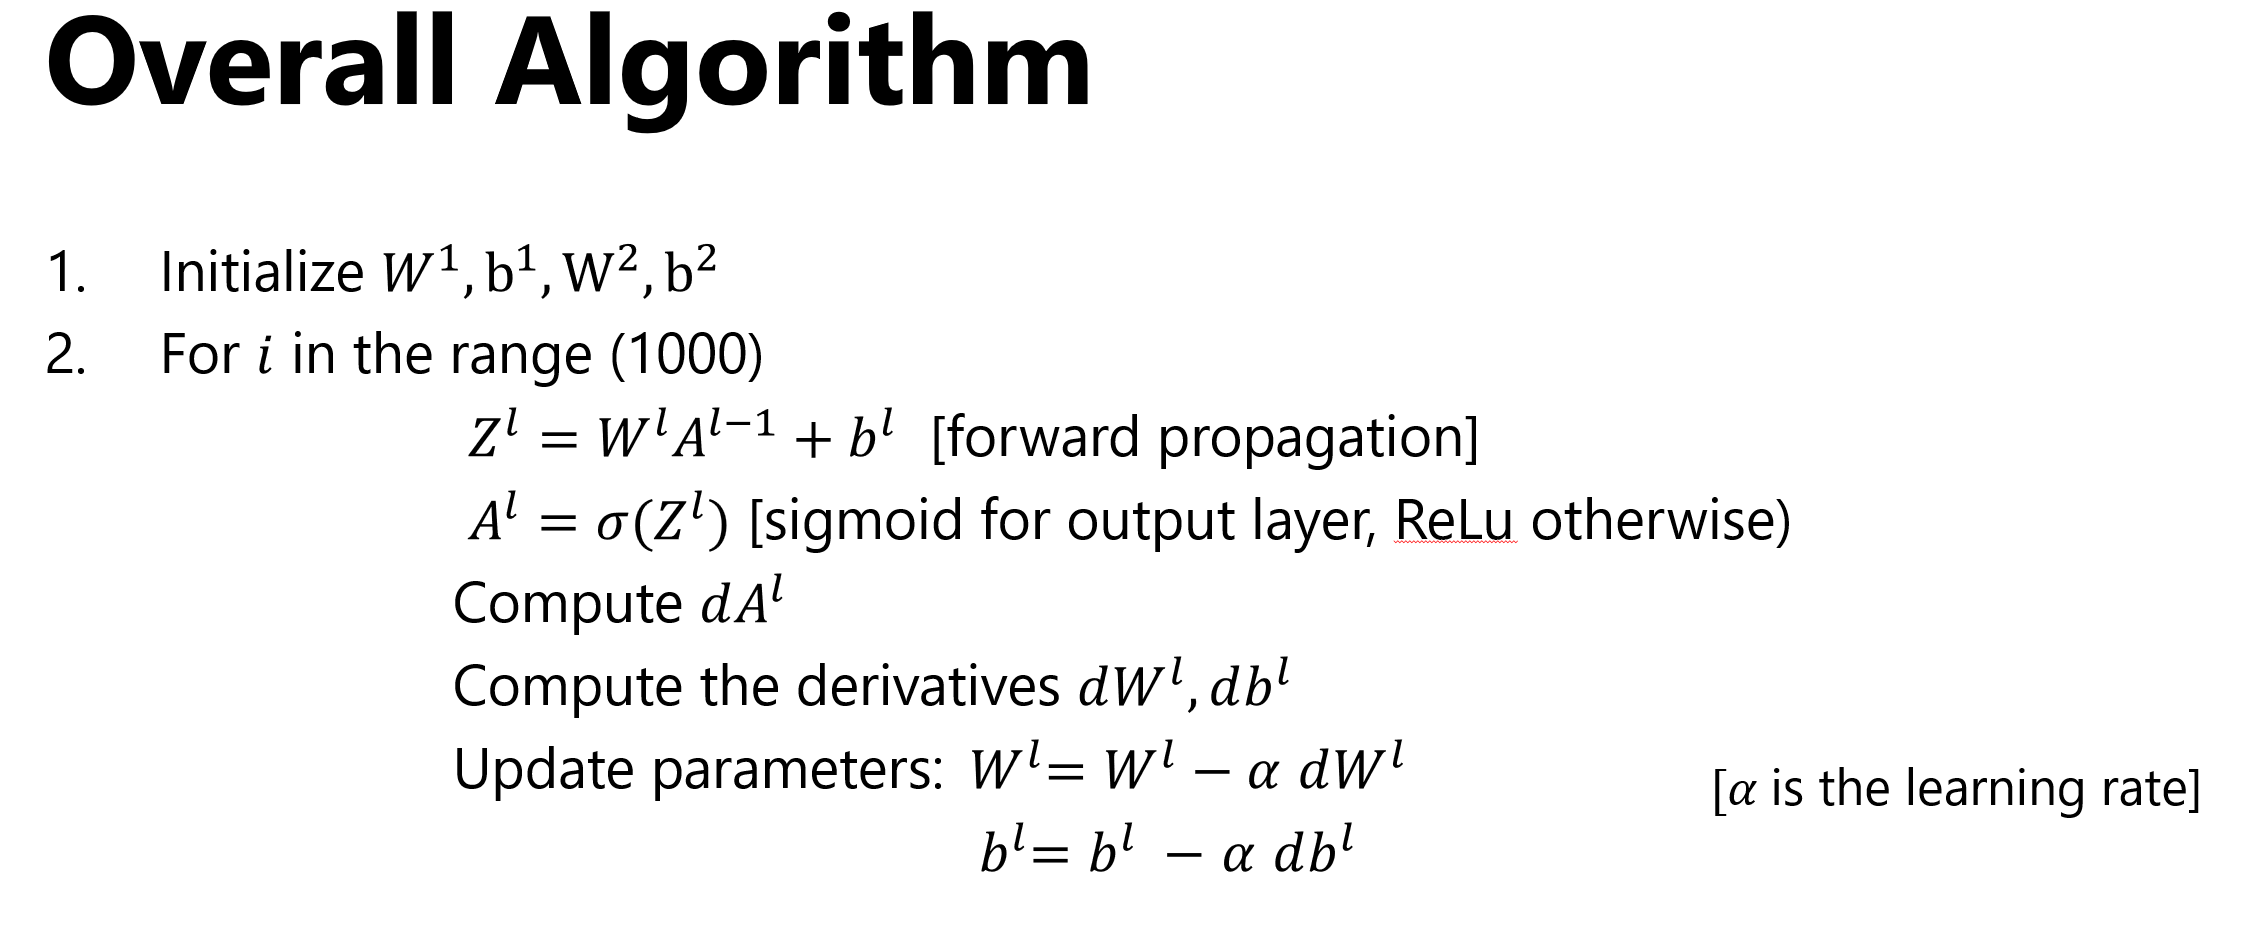

In [ ]:
### CONSTANTS DEFINING THE MODEL ####
n_x = 12288     # num_px * num_px * 3
n_h = 7
n_y = 1
layers_dims = (n_x, n_h, n_y)

In [ ]:
# Graded Activity 10
def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 2500, print_cost=False):
    """
    Implements a two-layer neural network: LINEAR->RELU->LINEAR->SIGMOID.

    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat), of shape (1, number of examples)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- If set to True, this will print the cost every 100 iterations

    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """

    np.random.seed(1)
    grads = {}
    costs = []                              # to keep track of the cost
    m = X.shape[1]                           # number of examples
    (n_x, n_h, n_y) = layers_dims

    # Initialize parameters dictionary, by calling one of the functions you'd previously implemented, HINT: initialize_parameters()
    parameters = initialize_parameters(n_x, n_h, n_y)


    # Get W1, b1, W2 and b2 from the dictionary parameters.
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    # Loop (gradient descent)

    for i in range(0, num_iterations):

        # Forward propagation: LINEAR -> RELU -> LINEAR -> SIGMOID. Inputs: "X, W1, b1". Output: "A1, cache1, A2, cache2". HINT: linear_activation_forward() with appropriate arguemnts for each layer
        A1, cache1 = linear_activation_forward(X, W1, b1, activation='relu')
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation='sigmoid')


        # Compute cost. Use the function you have implemented with appropriate arguemnts
        cost = compute_cost(A2, Y)


        # Initializing backward propagation. This is the derivative of the binary cross entropy function
        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))

        # Backward propagation. Inputs: "dA2, cache2, cache1". Outputs: "dA1, dW2, db2; also dA0 (not used), dW1, db1". HINT: linear_activation_backward() with the correct arguments for each layer
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation='sigmoid')
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation='relu')


        # Set grads['dWl'] to dW1, grads['db1'] to db1, grads['dW2'] to dW2, grads['db2'] to db2
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2

        # Update parameters. Use the function implemented above.
        parameters = update_parameters(parameters, grads, learning_rate)


        # Retrieve W1, b1, W2, b2 from parameters
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]

        # Print the cost every 100 training example
        if print_cost and i % 100 == 0:
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if print_cost and i % 100 == 0:
            costs.append(cost)

    # plot the cost

    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per tens)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

Run the cell below to train your parameters. See if your model runs. The cost should be decreasing. It may take up to 5 minutes to run 2500 iterations. Check if the "Cost after iteration 0" matches the expected output below, if not click on the square (⬛) on the upper bar of the notebook to stop the cell and try to find your error.

Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912677
Cost after iteration 300: 0.6015024920354665
Cost after iteration 400: 0.5601966311605747
Cost after iteration 500: 0.5158304772764729
Cost after iteration 600: 0.4754901313943325
Cost after iteration 700: 0.43391631512257495
Cost after iteration 800: 0.40079775362038866
Cost after iteration 900: 0.3580705011323798
Cost after iteration 1000: 0.3394281538366413
Cost after iteration 1100: 0.3052753636196263
Cost after iteration 1200: 0.27491377282130164
Cost after iteration 1300: 0.24681768210614832
Cost after iteration 1400: 0.19850735037466102
Cost after iteration 1500: 0.1744831811255665
Cost after iteration 1600: 0.17080762978096034
Cost after iteration 1700: 0.11306524562164738
Cost after iteration 1800: 0.09629426845937152
Cost after iteration 1900: 0.08342617959726865
Cost after iteration 2000: 0.07439078704319085
Cost after iteration 2100: 0.06630748

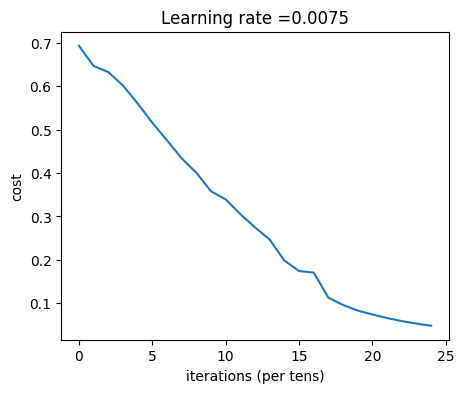

In [ ]:
parameters = two_layer_model(train_set_x, train_set_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)

Expected Output:

**Cost after iteration 0**=	0.6930497356599888

**Cost after iteration 100**=	0.6464320953428849

**...**	...

**Cost after iteration 2400**=	0.048554785628770206

Kudos on your vectorized implementation! Without it, we might have been looking at a training duration about ten times longer.

Now, you can use the trained parameters to classify images from the dataset. To see your predictions on the training and test sets, run the cell below.

In [ ]:
def L_model_forward(X, parameters):
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID computation

    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()

    Returns:
    AL -- last post-activation value
    caches -- list of caches containing:
                every cache of linear_relu_forward() (there are L-1 of them, indexed from 0 to L-2)
                the cache of linear_sigmoid_forward() (there is one, indexed L-1)
    """

    caches = []
    A = X

    L = len(parameters) // 2 # number of layers in the neural network

    # Implement [LINEAR -> RELU]*(L-1). Add "cache" to the "caches" list.
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], activation = "relu")
        caches.append(cache)

    # Implement LINEAR -> SIGMOID. Add "cache" to the "caches" list.
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], activation = "sigmoid")
    caches.append(cache)

    assert(AL.shape == (1,X.shape[1]))

    return AL, caches

def predict(X, y, parameters):
    """
    This function is used to predict the results of a  2-layer neural network.

    Arguments:
    X -- data set of examples you would like to label
    parameters -- parameters of the trained model

    Returns:
    p -- predictions for the given dataset X
    """

    m = X.shape[1]
    n = len(parameters) // 2 # number of layers in the neural network
    p = np.zeros((1,m))

    # Forward propagation
    probas, caches = L_model_forward(X, parameters)


    # convert probas to 0/1 predictions
    for i in range(0, probas.shape[1]):
        if probas[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0

    #print results
    #print ("predictions: " + str(p))
    #print ("true labels: " + str(y))
    print("Accuracy: "  + str(np.sum((p == y)/m)))

    return p

In [ ]:
predictions_train = predict(train_set_x, train_set_y, parameters)

Accuracy: 0.9999999999999998


In [ ]:
predictions_test = predict(test_set_x, test_set_y, parameters)

Accuracy: 0.72


Let's look at some correct predictions by our model.

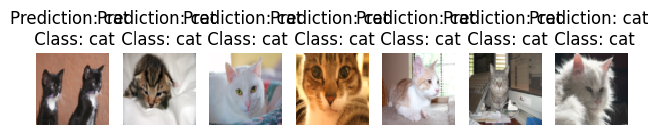

In [ ]:
correct_predictions(classes, test_set_x, test_set_y, predictions_test)

Let's check some incorrect prediction by our model.

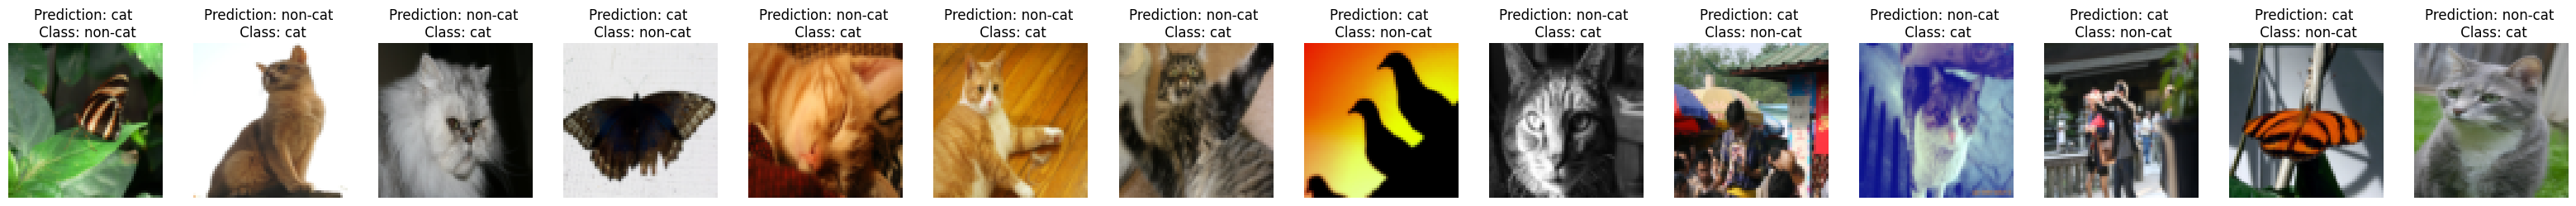

In [ ]:
print_mislabeled_images(classes, test_set_x, test_set_y, predictions_test)

# **5. Implement the Model using TensorFlow Framework (Ungraded-Do it after our discussion on Tensor flow)**


So far, you have made several helper functions to implement a two layer model to learn the basics of neural network implementation. Now we will step you through a deep learning framework Tensorflow (https://www.tensorflow.org) that will allow you to build neural networks quickly without too much coding. Machine learning frameworks like TensorFlow, PaddlePaddle, Torch, Caffe, Keras, and many others can speed up your machine learning development significantly. We encourage you to go through the tutorials of Tensorflow, https://www.tensorflow.org/tutorials.  All of these frameworks also have a lot of documentation which you should feel free to read at your convenience.

Now we will implement the same model built on section 3 but with tensorflow. You will understand how useful these frameworks can be.

**Imports:**

First let us import some important classes from tensorflow library to build the two layer neural network.

In [ ]:
from tensorflow.keras.models import Sequential #Used to build the sequential model.
from tensorflow.keras.layers import Dense, Input # The dense layer (similar to linear_forward) and input layer to be used in the model.

Now you will build the two layer neural network in just three lines on code!!!

In the model we will add the hidden layers with their following activation using the following code.

You can add the first layer with 7 hidden units followed by relu activation using `model.add(Dense(7, activation='relu'))`

Next we have to add the second layer with 1 hidden units followed by sigmoid activation using `model.add(Dense(1, activation='sigmoid'))`  


In [ ]:

model = Sequential()
model.add(Input(shape=(12288,)))
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

The following code compiles the model with the binary cross entropy loss function and gradient descent optimizer.

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='SGD',metrics=['accuracy'])

Here we transpose our test/train data for feeding it to the model for training

In [ ]:
train_set_y_New=train_set_y.T
test_set_y_New=test_set_y.T
train_set_x_New=train_set_x.T
test_set_x_New=test_set_x.T
print(train_set_y_New.shape)
print(test_set_y_New.shape)
print(train_set_x_New.shape)
print(test_set_x_New.shape)

(209, 1)
(50, 1)
(209, 12288)
(50, 12288)


Finally, let us train the model and see the results with same 2500 iterations.

In [ ]:
model.fit(train_set_x_New, train_set_y_New, epochs=2500, validation_data=(test_set_x_New, test_set_y_New))

Streaming output truncated to the last 5000 lines.
Epoch 1/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5975 - loss: 0.6849 - val_accuracy: 0.4200 - val_loss: 0.7189
Epoch 2/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6244 - loss: 0.6492 - val_accuracy: 0.3400 - val_loss: 0.8576
Epoch 3/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6728 - loss: 0.6453 - val_accuracy: 0.3400 - val_loss: 0.8466
Epoch 4/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6603 - loss: 0.6387 - val_accuracy: 0.3400 - val_loss: 0.8268
Epoch 5/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6483 - loss: 0.6388 - val_accuracy: 0.3400 - val_loss: 0.8164
Epoch 6/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6584 - loss: 0.6654 - val_accuracy: 0.3400 - val_loss: 0.8138
Epoch 7/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6550 - loss: 0.6303 - val_accuracy: 0.3400 - val_loss: 0.7917
Epoch 8/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6

In [ ]:
prediction = model.predict(test_set_x_New)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [ ]:
prediction_transpose = prediction.T

In [ ]:
print(prediction_transpose.shape)

(1, 50)


Let's have a look at the predictions

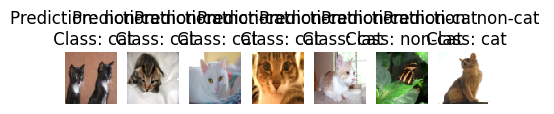

In [ ]:
correct_predictions(classes, test_set_x, test_set_y, prediction_transpose)

#**6. Evaluation Details**
This assignment is meant to be done in three recitations (Oct. 2, Oct. 9, Oct. 16). You will get a total of 15 days to complete the activities. Attendance in each recitation is mandatory to get marks for the graded activities. We will record your attendance. If you complete all the activities in the first recitation itself, then the second recitation is optional. You have to read the instructions, refer to the slides and do all the exercises, refer to the materials as and when necessary (especially for syntaxes). The marker reserves the prerogative to pose supplementary questions for elucidation when deemed necessary.

**NOTE** If you are unable to attend the recitation, please notify the instructor prior to the session. Absences due to illness or other valid reasons will be taken into consideration.

#**7. References/Source**
1. Dataset and the project courtesy: Prof. Andrew Ng, Stanford University
2. Richard Szeleski, Computer Vision: Algorithms and Applications, Second edition